
# Do time-aware transaction features explain and predict arrears better than static attributes?

**Core objective:** show, with a controlled comparison, that *time-aware* transactional features
(trends, volatility, recency, short vs long windows) explain and predict `target_value`
(1 = fewer payments made than due in the 3 months after M0) **better than static, point-in-time attributes**.

**Hypotheses (declared up front)**
* **H1** Time-aware features alone outperform static account attributes alone.
* **H2** Time-aware features add predictive and explanatory power on top of the best *non-temporal* baseline
  (static attributes + balance snapshot + time-agnostic 90-day aggregates).
* **H3** The gain comes from *timing/ordering*, not just from having more transaction data: if we shuffle the
  timing of each customer's transactions (placebo), the gain should disappear.

**Controls that keep the comparison fair**
* Identical customers, identical out-of-time split (train on earlier M0 months, test on later ones), same model classes and tuning budget for every feature set.
* Features use only information at or before M0. Outcome-period columns (`payment_count`, `total_paid`) are excluded.
* A "ladder" of feature sets (static, + snapshot, + flat aggregates, time-aware, full) isolates what timing adds.
* Paired bootstrap confidence intervals on test-set differences, plus nested likelihood-ratio tests and grouped CV as robustness checks.

**Sections**
1. Setup and configuration
2. Load, types, data quality
3. Grain of the data
4. Target analysis and label validation
5. Account-level variables vs target
6. Transaction-level overview
7. Time windows and leakage checks
8. Feature construction: static vs time-aware
9. Exploratory view of the temporal signal
10. Model comparison framework (out-of-time split)
11. Results: static vs time-aware
12. Statistical significance and explanatory power
13. Ablation: which temporal features matter
14. Placebo test: does timing matter?
15. Robustness (cohorts, grouped CV)
16. Verdict and outputs


## 1. Setup and configuration

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

In [2]:
# ---------------- CONFIG: edit these ----------------
PARQUET_PATH = "collections_data.parquet"   # path to your parquet file
WINDOW_DAYS = 90                        # behavioural look-back window before M0
SAMPLE_CUSTOMERS = None                 # e.g. 20000 to sample customers for speed; None = all
DEDUPE_TXNS = False                     # see section 3 diagnostic before switching on
OUTPUT_PATH = "customer_features.parquet"

# Column names (from the data dictionary)
ID, M0, TARGET = "cifwithcheckdigit", "m0_monthenddate", "target_value"
PAY_DATE = "payment_date"
TXN_DATE, TXN_TYPE, AMT, BAL = "transactiondate", "trantypedesc", "amount", "balance"
SPEND, CAT, METHOD = "spendgroup", "categoryname", "collectionsmethodname"

CUST_NUM = ["m0_arrearsamount", "due_count", "payment_count",
            "m0_total_due_with_arrears", "total_paid"]
CUST_COLS = CUST_NUM + [TARGET, METHOD]
TXN_COLS = [TXN_DATE, TXN_TYPE, AMT, BAL, SPEND, CAT]
DATE_COLS = [M0, PAY_DATE, TXN_DATE]
CATEGORICAL = [TXN_TYPE, SPEND, CAT, METHOD]

# Columns that are only known AFTER M0 (outcome-related): never use as model/SOM inputs
LEAKY = ["payment_count", "total_paid", TARGET]

## 2. Load, types and data quality

In [3]:
df = pd.read_parquet(PARQUET_PATH)

expected = [ID, M0, PAY_DATE] + CUST_COLS + TXN_COLS
missing_cols = [c for c in expected if c not in df.columns]
extra_cols = [c for c in df.columns if c not in expected]
print("Missing expected columns:", missing_cols)
print("Extra columns           :", extra_cols)

for c in DATE_COLS:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")
for c in CATEGORICAL:
    if c in df.columns:
        df[c] = df[c].astype("category")
df[ID] = df[ID].astype(str)

if SAMPLE_CUSTOMERS:
    keep = pd.Series(df[ID].unique()).sample(SAMPLE_CUSTOMERS, random_state=42)
    df = df[df[ID].isin(keep)].copy()

print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
display(df.dtypes.to_frame("dtype"))
display(df.head())

Missing expected columns: []
Extra columns           : []

Shape: 52,025,014 rows x 16 columns
Memory: 3,589.7 MB


,dtype
cifwithcheckdigit,str
m0_monthenddate,datetime64[s]
m0_arrearsamount,float32
due_count,uint8
payment_count,uint8
m0_total_due_with_arrears,float32
total_paid,float32
target_value,int8
payment_date,datetime64[s]
collectionsmethodname,category


,cifwithcheckdigit,m0_monthenddate,m0_arrearsamount,due_count,payment_count,m0_total_due_with_arrears,total_paid,target_value,payment_date,collectionsmethodname,transactiondate,trantypedesc,amount,balance,spendgroup,categoryname
0,253822742,2026-01-31,"1,213.6400",3,1,"4,833.5400","1,000.0000",1,2026-01-31,"Early Debit Order, linked to clients paydate",2026-01-21 12:54:20.239,Immediate Capitec Pay Payment,-200.0000,30.0000,CapitecPay,Betting/Lottery
1,278859100,2026-01-31,922.4800,3,6,"3,649.5500","22,652.7695",0,2026-01-26,Debit Order,2026-01-21 05:17:22.609,Card Purchase,-49.9800,282.6000,CardAuthorisationTransaction,Groceries
2,111820626,2026-02-28,"2,208.6399",3,6,"7,712.2900","7,712.2900",0,2026-02-15,Debit Order,2026-01-18 16:26:08.035,Card Purchase,-100.0000,480.6100,CardTransaction,Fuel
3,139747958,2026-01-31,"1,544.0000",3,5,"6,387.2900","6,387.2900",0,2026-01-25,Debit Order,2026-01-20 23:30:21.432,Live Better Round-up Transfer,-8.1000,423.0800,InternalTransfer,Transfer
4,289894417,2026-02-28,"3,662.6399",3,2,"13,713.5498","7,142.1699",1,2026-02-15,Debit Order,2026-01-21 12:27:40.880,Payment Received,"1,600.0000","1,690.9500",MoneyIn,Other Income


In [4]:
# Missing values, cardinality, duplicates
dq = pd.DataFrame({
    "missing_n": df.isna().sum(),
    "missing_%": df.isna().mean() * 100,
    "n_unique": df.nunique(),
})
display(dq.sort_values("missing_%", ascending=False))

print(f"Fully duplicated rows: {df.duplicated().sum():,} ({df.duplicated().mean():.2%})")

for c in DATE_COLS:
    if c in df.columns:
        print(f"{c:20s} min={df[c].min()}  max={df[c].max()}  unparseable/NaT={df[c].isna().sum():,}")

display(df.select_dtypes("number").describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

,missing_n,missing_%,n_unique
cifwithcheckdigit,0,0.0000,120424
m0_monthenddate,0,0.0000,6
m0_arrearsamount,0,0.0000,89890
due_count,0,0.0000,3
payment_count,0,0.0000,87
m0_total_due_with_arrears,0,0.0000,109842
total_paid,0,0.0000,83817
target_value,0,0.0000,2
payment_date,0,0.0000,181
collectionsmethodname,0,0.0000,3


Fully duplicated rows: 12,623,849 (24.26%)
m0_monthenddate      min=2025-09-30 00:00:00  max=2026-02-28 00:00:00  unparseable/NaT=0
payment_date         min=2025-09-01 00:00:00  max=2026-02-28 00:00:00  unparseable/NaT=0
transactiondate      min=2025-05-01 08:53:26.135000  max=2026-02-27 20:47:20.460000  unparseable/NaT=0


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
m0_arrearsamount,"52,025,014.0000","1,402.8500","2,298.5156",50.0000,80.5700,177.0200,438.3800,840.4900,"1,690.2600","4,196.3501","8,444.6396","333,902.2188"
due_count,"52,025,014.0000",2.9790,0.1728,1.0000,2.0000,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000
payment_count,"52,025,014.0000",3.9932,4.4630,0.0000,0.0000,0.0000,2.0000,4.0000,5.0000,9.0000,19.0000,161.0000
m0_total_due_with_arrears,"52,025,014.0000","5,123.6167","7,463.5791",-596.6200,439.3000,821.9100,"1,683.5300","3,203.3000","6,329.9199","14,741.8203","29,721.3594","1,138,196.3750"
total_paid,"52,025,014.0000","6,174.5317","19,270.1289","-13,311.2197",0.0000,0.0000,686.4000,"2,331.7900","5,970.0000","22,118.1895","63,142.0898","1,346,658.0000"
target_value,"52,025,014.0000",0.4030,0.4905,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
amount,"52,025,014.0000",-15.0994,"4,992.9639","-3,000,000.0000","-4,900.0000","-1,300.0000",-212.1000,-59.0000,-6.0000,"1,000.0000","6,800.0000","3,501,550.0000"
balance,"52,025,014.0000","2,306.3821","20,631.5879","-565,966.8125","-42,124.4805","-7,349.7834",159.9500,823.4400,"2,957.1599","14,624.8096","42,755.0703","9,169,039.0000"


## 3. Grain of the data

The file looks like customer-level fields (`m0_*`, `due_count`, `target_value`, ...) joined to
transaction-level fields. Before aggregating we need to know:
* How many customers / M0 snapshots are there?
* Are the customer-level columns constant within a customer?
* Is there evidence of a **row explosion** (e.g. several `payment_date` rows per customer multiplied
  against every transaction), which would duplicate transactions and inflate sums?

In [5]:
KEY = [ID, M0]
n_cust = df[ID].nunique()
n_keys = df[KEY].drop_duplicates().shape[0]
print(f"Unique customers        : {n_cust:,}")
print(f"Unique (customer, M0)   : {n_keys:,}")
print(f"Customers with >1 M0    : {(df.groupby(ID)[M0].nunique() > 1).sum():,}")

rows_per_key = df.groupby(KEY, dropna=False).size()
display(rows_per_key.describe().to_frame("rows per (customer, M0)").T)

# Are customer-level columns constant within a (customer, M0)?
chk = {}
for c in [c for c in CUST_COLS if c in df.columns]:
    chk[c] = (df.groupby(KEY, dropna=False)[c].nunique(dropna=False) > 1).mean()
chk[PAY_DATE] = (df.groupby(KEY, dropna=False)[PAY_DATE].nunique(dropna=False) > 1).mean()
display(pd.Series(chk, name="share of keys where value varies").to_frame())

Unique customers        : 120,424
Unique (customer, M0)   : 120,424
Customers with >1 M0    : 0


,count,mean,std,min,25%,50%,75%,max
"rows per (customer, M0)","120,424.0000",432.0153,381.2404,2.0000,160.0000,327.0000,588.0000,"8,232.0000"


,share of keys where value varies
m0_arrearsamount,0.0000
due_count,0.0000
payment_count,0.0000
m0_total_due_with_arrears,0.0000
total_paid,0.0000
target_value,0.0000
collectionsmethodname,0.0000
payment_date,0.0000


In [6]:
# Row-explosion diagnostic: identical transactions repeated within a customer
txn_key_cols = [ID, M0] + [c for c in TXN_COLS if c in df.columns]
dup_txn = df.duplicated(subset=txn_key_cols, keep="first")
print(f"Rows duplicated on all transaction fields: {dup_txn.sum():,} ({dup_txn.mean():.2%})")

pay_per_key = df.groupby(KEY, dropna=False)[PAY_DATE].nunique()
print(f"Median distinct payment_date per key: {pay_per_key.median():.0f}  (max {pay_per_key.max()})")
if dup_txn.mean() > 0.2 and pay_per_key.median() > 1:
    print("\nWARNING: transactions look repeated once per payment_date. "
          "Consider setting DEDUPE_TXNS = True so sums/counts are not inflated.")

# Customer-level table (one row per customer / M0) and payment-level table
cust = (df.groupby(KEY, dropna=False)[[c for c in CUST_COLS if c in df.columns]]
          .first().reset_index())
pay = df[KEY + [PAY_DATE]].drop_duplicates()

# Transaction-level table
txn = df[KEY + [c for c in TXN_COLS if c in df.columns]].copy()
txn = txn.dropna(subset=[TXN_DATE])
# Duplicates are handled per customer batch in section 8 (DEDUPE_TXNS) to avoid a 52M-row global drop_duplicates.
print(f"cust: {cust.shape}, pay: {pay.shape}, txn: {txn.shape}")

Rows duplicated on all transaction fields: 12,623,849 (24.26%)
Median distinct payment_date per key: 1  (max 1)
cust: (120424, 9), pay: (120424, 3), txn: (52025014, 8)


## 4. Target analysis and label validation

target_value
0    68042
1    52382

Positive rate (missed payments): 43.50%   |   imbalance ratio ~ 1:1.3


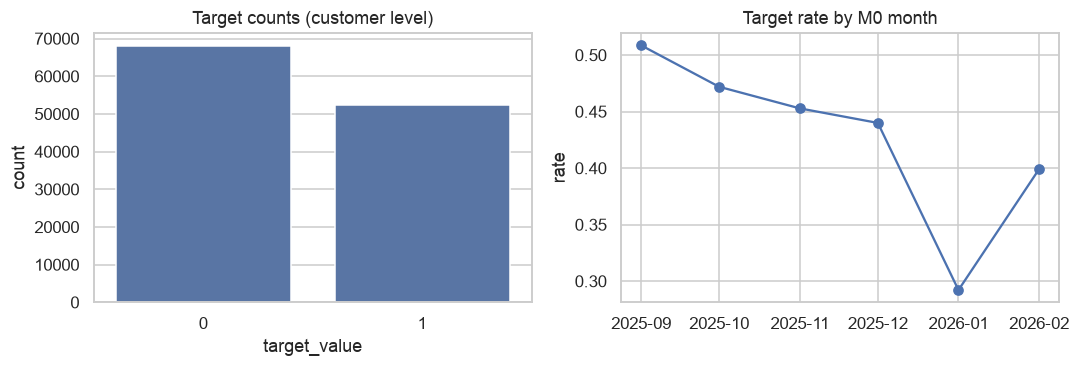

,target_rate,n_customers
month,,
2025-09-01,0.5086,35252
2025-10-01,0.4719,19489
2025-11-01,0.4528,14262
2025-12-01,0.4399,15127
2026-01-01,0.2921,21887
2026-02-01,0.3991,14407


In [7]:
vc = cust[TARGET].value_counts(dropna=False).sort_index()
rate = cust[TARGET].mean()
print(vc.to_string())
print(f"\nPositive rate (missed payments): {rate:.2%}   |   imbalance ratio ~ 1:{(1-rate)/rate:,.1f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.countplot(x=TARGET, data=cust, ax=ax[0])
ax[0].set_title("Target counts (customer level)")
tmp = cust.dropna(subset=[M0]).assign(month=lambda d: d[M0].dt.to_period("M").dt.to_timestamp())
m = tmp.groupby("month")[TARGET].agg(["mean", "count"])
ax[1].plot(m.index, m["mean"], marker="o")
ax[1].set_title("Target rate by M0 month"); ax[1].set_ylabel("rate")
plt.tight_layout(); plt.show()
display(m.rename(columns={"mean": "target_rate", "count": "n_customers"}))

In [8]:
# Validate the label definition: target = 1 if payment_count < due_count
if {"payment_count", "due_count"} <= set(cust.columns):
    derived = (cust["payment_count"] < cust["due_count"]).astype(int)
    mismatch = (derived != cust[TARGET])
    print(f"Label disagrees with (payment_count < due_count) for {mismatch.sum():,} rows ({mismatch.mean():.2%})")
    if mismatch.any():
        display(cust.loc[mismatch, ["due_count", "payment_count", TARGET]].head(10))
    display(pd.crosstab(cust["due_count"], cust["payment_count"], margins=True))

Label disagrees with (payment_count < due_count) for 19,401 rows (16.11%)


,due_count,payment_count,target_value
6,3,5,1
10,3,3,1
13,3,3,1
20,3,3,1
23,3,1,0
40,3,6,1
41,3,2,0
59,3,4,1
72,2,1,0
78,3,3,1


payment_count,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,58,60,61,62,63,64,65,66,67,69,70,71,72,73,74,75,77,78,83,84,85,86,91,94,95,107,109,113,121,161,All
due_count,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,109,113,177,96,41,21,12,8,3,2,7,1,3,0,1,4,1,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,604
2,225,180,192,209,154,120,67,44,44,30,20,16,13,16,8,5,6,6,3,7,4,2,2,1,2,1,2,1,5,1,0,1,1,0,3,1,0,0,0,0,1,0,0,0,1,0,2,0,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1401
3,21479,7636,10712,18889,29590,12004,8766,3502,1754,1079,689,446,337,241,192,150,121,107,90,70,61,40,48,42,27,38,25,15,31,14,29,13,6,16,12,10,10,6,8,6,3,8,4,4,3,4,13,4,3,4,2,2,2,1,4,1,2,1,2,1,1,6,3,1,1,1,2,2,1,1,3,1,1,3,0,1,1,1,1,1,1,1,1,1,1,2,1,118419
All,21813,7929,11081,19194,29785,12145,8845,3554,1801,1111,716,463,353,257,201,159,128,114,93,77,65,43,50,44,29,39,27,16,37,15,29,14,8,16,15,11,10,6,8,6,4,8,4,4,4,4,15,4,5,4,2,3,2,1,4,1,2,1,2,1,1,6,3,1,1,1,2,2,1,1,3,1,1,3,1,1,1,1,1,1,1,2,1,1,1,2,1,120424


## 5. Customer-level (account) variables vs target

Note: `payment_count` and `total_paid` describe the outcome period, so they are shown here for
understanding and label validation only. They must **not** be used as predictors.

In [9]:
def slog(x):
    """Signed log transform, handles zero/negative values."""
    return np.sign(x) * np.log1p(np.abs(x))

c = cust.copy()
if {"payment_count", "due_count"} <= set(c.columns):
    c["payment_ratio"] = c["payment_count"] / c["due_count"].replace(0, np.nan)
if {"total_paid", "m0_total_due_with_arrears"} <= set(c.columns):
    c["paid_to_due_ratio"] = c["total_paid"] / c["m0_total_due_with_arrears"].replace(0, np.nan)
if {"m0_arrearsamount", "m0_total_due_with_arrears"} <= set(c.columns):
    c["arrears_share_of_due"] = c["m0_arrearsamount"] / c["m0_total_due_with_arrears"].replace(0, np.nan)

num_cols = [x for x in CUST_NUM + ["payment_ratio", "paid_to_due_ratio", "arrears_share_of_due"] if x in c.columns]
display(c.groupby(TARGET)[num_cols].describe().T)

target_value                                 0            1
m0_arrearsamount          count    68,042.0000  52,382.0000
                          mean      1,088.9927   1,322.4849
                          std       1,895.2084   2,196.5491
                          min          50.0000      50.0000
                          25%         352.7000     413.4125
                          50%         667.7500     744.9650
                          75%       1,326.4900   1,496.4725
                          max     333,902.2188 180,875.3125
due_count                 count    68,042.0000  52,382.0000
                          mean          2.9701       2.9890
                          std           0.2094       0.1210
                          min           1.0000       1.0000
                          25%           3.0000       3.0000
                          50%           3.0000       3.0000
                          75%           3.0000       3.0000
                          max           3.0000       3.0000
payment_count             count    68,042.0000  52,382.0000
                          mean          4.8301       1.7753
                          std           3.7054       2.1253
                          min           0.0000       0.0000
                          25%           4.0000       0.0000
                          50%           4.0000       1.0000
                          75%           5.0000       3.0000
                          max         161.0000      60.0000
m0_total_due_with_arrears count    68,042.0000  52,382.0000
                          mean      4,157.1611   4,398.1138
                          std       6,378.7974   6,551.9761
                          min        -596.6200     -29.7100
                          25%       1,428.9200   1,335.3775
                          50%       2,627.2250   2,425.0050
                          75%       5,191.5502   5,060.1774
                          max   1,138,196.3750 205,783.0781
total_paid                count    68,042.0000  52,382.0000
                          mean      7,529.3921   1,003.4232
                          std      20,028.6875   2,386.5090
                          min     -13,311.2197  -9,070.0000
                          25%       1,673.1600       0.0000
                          50%       3,317.2700     100.0000
                          75%       7,247.4799   1,058.3375
                          max   1,346,658.0000 145,700.0000
payment_ratio             count    68,042.0000  52,382.0000
                          mean          1.6393       0.5931
                          std           1.3153       0.7091
                          min           0.0000       0.0000
                          25%           1.3333       0.0000
                          50%           1.3333       0.3333
                          75%           1.6667       1.0000
                          max          53.6667      20.0000
paid_to_due_ratio         count    68,042.0000  52,382.0000
                          mean          2.1479       0.2528
                          std           6.5294       0.5515
                          min         -34.8927      -1.4098
                          25%           1.0000       0.0000
                          50%           1.0000       0.0477
                          75%           1.3374       0.4964
                          max         813.6273      80.1607
arrears_share_of_due      count    68,042.0000  52,382.0000
                          mean          0.2682       0.3141
                          std           0.0869       0.1349
                          min          -0.3569     -14.6221
                          25%           0.2369       0.2531
                          50%           0.2658       0.3083
                          75%           0.3002       0.3489
                          max           1.3710       1.0000

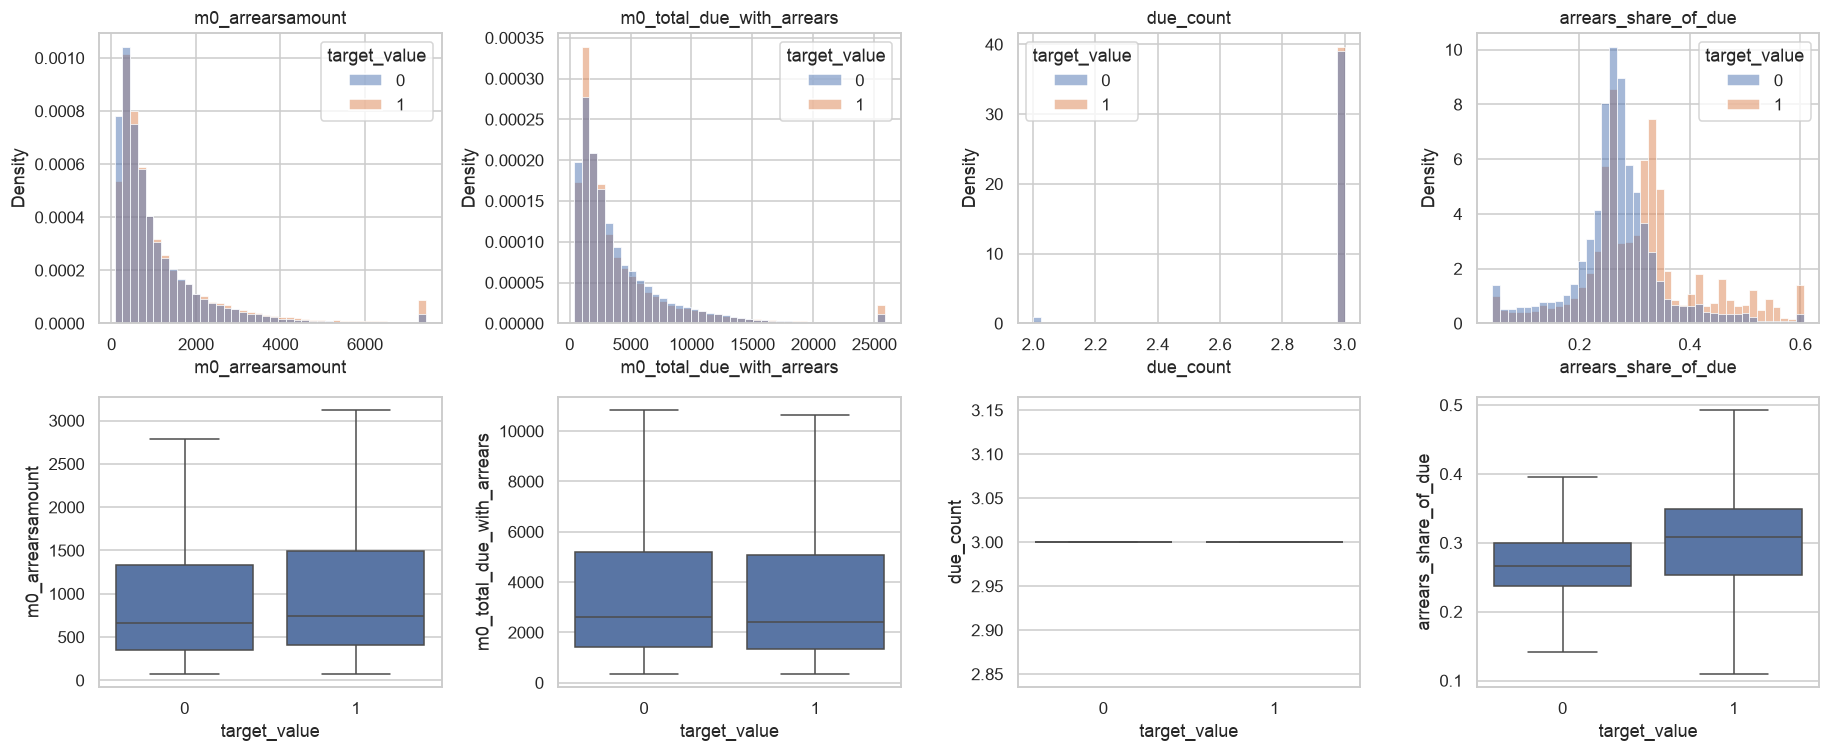

In [10]:
plot_cols = [x for x in ["m0_arrearsamount", "m0_total_due_with_arrears", "due_count", "arrears_share_of_due"] if x in c.columns]
fig, axes = plt.subplots(2, len(plot_cols), figsize=(4.2 * len(plot_cols), 7))
axes = np.atleast_2d(axes)
for i, col in enumerate(plot_cols):
    s = c[col].dropna()
    lo, hi = s.quantile([0.01, 0.99])
    d = c[[col, TARGET]].dropna()
    d[col] = d[col].clip(lo, hi)
    sns.histplot(data=d, x=col, hue=TARGET, stat="density", common_norm=False, bins=40, ax=axes[0, i])
    axes[0, i].set_title(col)
    sns.boxplot(data=d, x=TARGET, y=col, showfliers=False, ax=axes[1, i])
plt.tight_layout(); plt.show()

In [11]:
# Univariate separation of account-level (non-leaky) variables
rows = []
for col in [x for x in num_cols if x not in LEAKY and x not in ["payment_ratio", "paid_to_due_ratio"]]:
    a = c.loc[c[TARGET] == 1, col].dropna(); b = c.loc[c[TARGET] == 0, col].dropna()
    if len(a) > 20 and len(b) > 20:
        u, p = stats.mannwhitneyu(a, b)
        rows.append({"feature": col, "median_target1": a.median(), "median_target0": b.median(),
                     "AUC": u / (len(a) * len(b)), "p_value": p})
display(pd.DataFrame(rows).set_index("feature"))

,median_target1,median_target0,AUC,p_value
feature,,,,
m0_arrearsamount,744.9650,667.7500,0.5378,0.0000
due_count,3.0000,3.0000,0.5067,0.0000
m0_total_due_with_arrears,"2,425.0049","2,627.2251",0.4917,0.0000
arrears_share_of_due,0.3083,0.2658,0.6354,0.0000


,count,n_pos,rate,ci_lo,ci_hi,lift
collectionsmethodname,,,,,,
"Early Debit Order, linked to clients paydate",79080,40840,0.5164,0.5130,0.5199,1.1873
Debit Order,39521,11060,0.2799,0.2754,0.2843,0.6434
"Credit push, client pays via EFT",1823,482,0.2644,0.2447,0.2851,0.6078


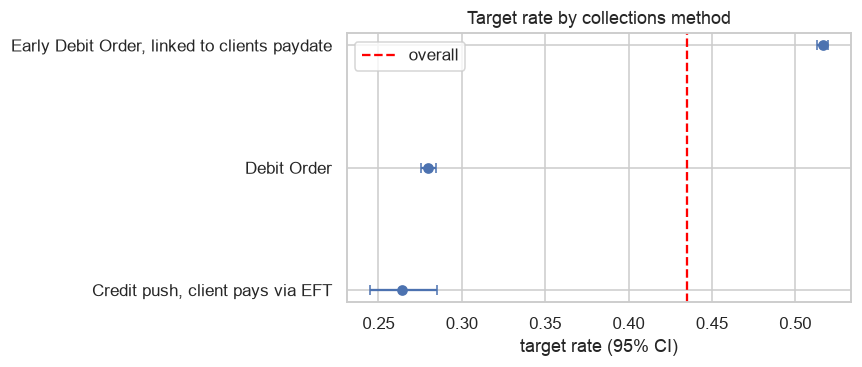

In [12]:
def rate_table(d, col, target=TARGET, min_n=30, top=None):
    """Target rate by category with Wilson 95% CI and lift vs overall rate."""
    g = d.groupby(col, observed=True)[target].agg(["count", "sum"]).rename(columns={"sum": "n_pos"})
    g["rate"] = g["n_pos"] / g["count"]
    lo, hi = proportion_confint(g["n_pos"], g["count"], method="wilson")
    g["ci_lo"], g["ci_hi"] = lo, hi
    g["lift"] = g["rate"] / d[target].mean()
    g = g[g["count"] >= min_n].sort_values("count", ascending=False)
    return g.head(top) if top else g

if METHOD in cust.columns:
    rt = rate_table(cust, METHOD)
    display(rt)
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(rt) + 2))
    rt_s = rt.sort_values("rate")
    ax.errorbar(rt_s["rate"], range(len(rt_s)),
                xerr=[rt_s["rate"] - rt_s["ci_lo"], rt_s["ci_hi"] - rt_s["rate"]], fmt="o", capsize=3)
    ax.set_yticks(range(len(rt_s))); ax.set_yticklabels(rt_s.index)
    ax.axvline(cust[TARGET].mean(), color="red", ls="--", label="overall")
    ax.set_xlabel("target rate (95% CI)"); ax.set_title("Target rate by collections method"); ax.legend()
    plt.tight_layout(); plt.show()

## 6. Transaction-level overview

Transactions: 52,025,014 across 120,424 customers
Date range  : 2025-05-01 -> 2026-02-27


,count,mean,std,min,5%,25%,50%,75%,95%,max
transactions per customer,"120,424.0000",432.0153,381.2404,2.0000,52.0000,160.0000,327.0000,588.0000,"1,165.0000","8,232.0000"



Inflows (amount>0): 22.6% of rows | outflows (amount<0): 77.4% | zero: 0.0%
Balance negative at transaction time: 7.5%


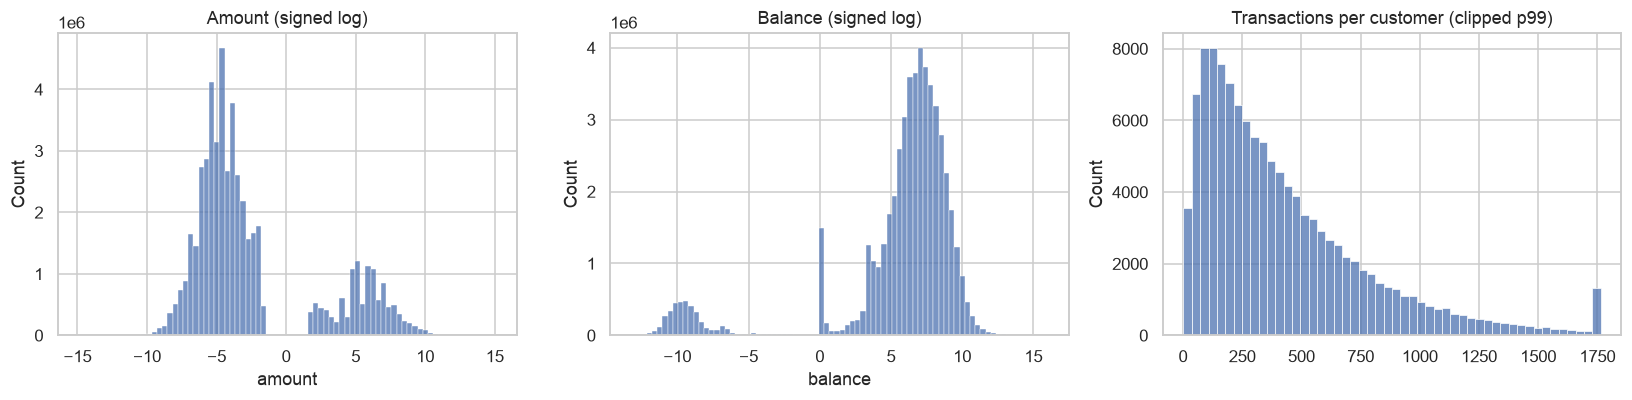

In [13]:
print(f"Transactions: {len(txn):,} across {txn[ID].nunique():,} customers")
print(f"Date range  : {txn[TXN_DATE].min().date()} -> {txn[TXN_DATE].max().date()}")

tpc = txn.groupby(KEY, dropna=False).size()
display(tpc.describe(percentiles=[.05, .25, .5, .75, .95]).to_frame("transactions per customer").T)

print(f"\nInflows (amount>0): {(txn[AMT] > 0).mean():.1%} of rows | outflows (amount<0): {(txn[AMT] < 0).mean():.1%} | zero: {(txn[AMT] == 0).mean():.1%}")
print(f"Balance negative at transaction time: {(txn[BAL] < 0).mean():.1%}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
sns.histplot(slog(txn[AMT].dropna()), bins=80, ax=ax[0]); ax[0].set_title("Amount (signed log)")
sns.histplot(slog(txn[BAL].dropna()), bins=80, ax=ax[1]); ax[1].set_title("Balance (signed log)")
sns.histplot(tpc.clip(upper=tpc.quantile(.99)), bins=50, ax=ax[2]); ax[2].set_title("Transactions per customer (clipped p99)")
plt.tight_layout(); plt.show()


=== trantypedesc: 249 levels (top 20 shown) ===


,n,net_amount,mean_amount,pct_inflow,share_%
trantypedesc,,,,,
Card Purchase,14936801,"-3,782,662,144.0000",-253.2445,0.0000,28.7108
Transfer,4645835,"-4,212,408,064.0000",-906.7064,0.0859,8.9300
Transfer Received,3929926,"4,681,745,408.0000","1,191.3063",1.0000,7.5539
Prepaid Purchase,3373328,"-162,207,408.0000",-48.0853,0.0000,6.4841
Payment Received,3249129,"9,109,794,816.0000","2,803.7651",1.0000,6.2453
Immediate Payment,2870817,"-2,655,650,560.0000",-925.0505,0.0000,5.5181
Voucher Purchase,1586090,"-173,098,128.0000",-109.1351,0.0000,3.0487
Cash Withdrawal,1441093,"-1,176,032,768.0000",-816.0700,0.0000,2.7700
Immediate Capitec Pay Payment,1335231,"-431,835,296.0000",-323.4162,0.0000,2.5665


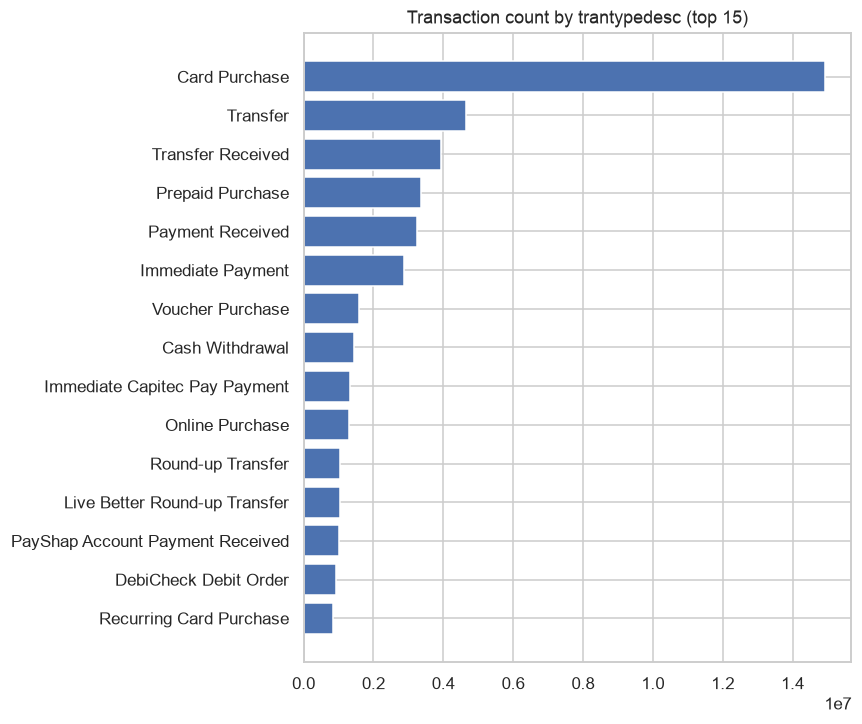


=== spendgroup: 38 levels (top 20 shown) ===


,n,net_amount,mean_amount,pct_inflow,share_%
spendgroup,,,,,
InternalTransfer,9724718,"426,290,848.0000",43.8358,0.4480,18.6924
CardAuthorisationTransaction,8751771,"-2,266,122,496.0000",-258.9330,0.0001,16.8222
CardTransaction,8554615,"-2,216,868,608.0000",-259.1430,0.0019,16.4433
MoneyIn,4434621,"10,210,201,600.0000","2,302.3843",0.9989,8.5240
Prepaid,3479421,"-158,104,736.0000",-45.4400,0.0270,6.6880
PaymentInternal,3112068,"-2,869,017,088.0000",-921.9005,0.0008,5.9819
Fee,1776238,"-24,395,192.0000",-13.7342,0.0179,3.4142
Vouchers,1589566,"-172,702,976.0000",-108.6479,0.0022,3.0554
CapitecPay,1408946,"-475,908,096.0000",-337.7760,0.0000,2.7082


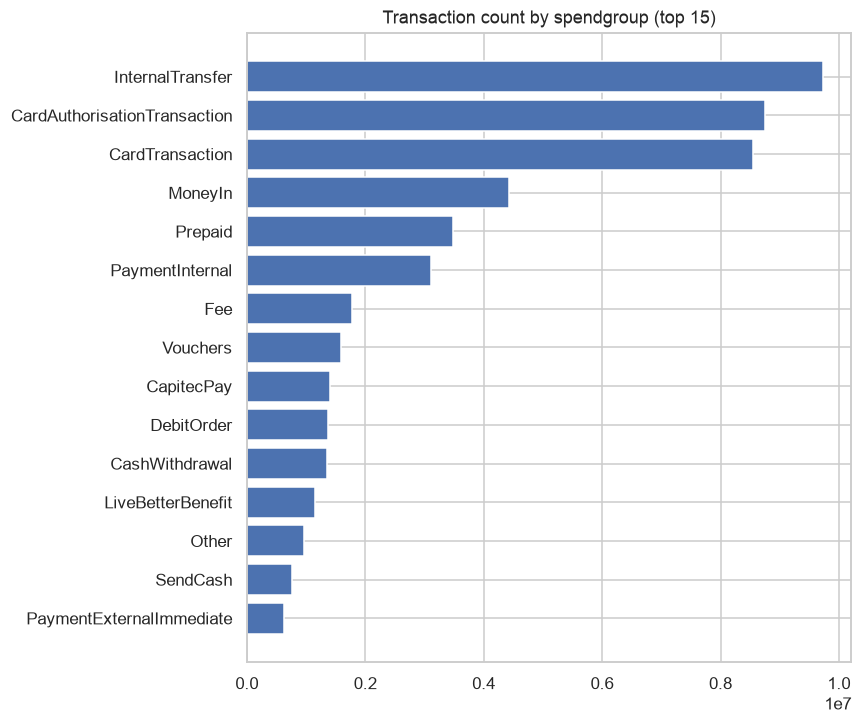


=== categoryname: 103 levels (top 20 shown) ===


,n,net_amount,mean_amount,pct_inflow,share_%
categoryname,,,,,
Transfer,9756191,"421,866,080.0000",43.2409,0.4482,18.7529
Groceries,7065448,"-1,568,931,712.0000",-222.0569,0.0001,13.5809
Cellphone,3755432,"-221,902,064.0000",-59.0883,0.0124,7.2185
Other Income,3684602,"5,519,918,080.0000","1,498.1042",0.9997,7.0824
Digital Payments,3437103,"-3,578,882,048.0000","-1,041.2496",0.0026,6.6066
Betting/Lottery,3366374,"-451,305,216.0000",-134.0627,0.0632,6.4707
Cash Withdrawal,2207426,"-1,506,041,344.0000",-682.2613,0.0231,4.2430
Fees,1776238,"-24,395,192.0000",-13.7342,0.0179,3.4142
Fuel,1652913,"-452,304,000.0000",-273.6405,0.0004,3.1772


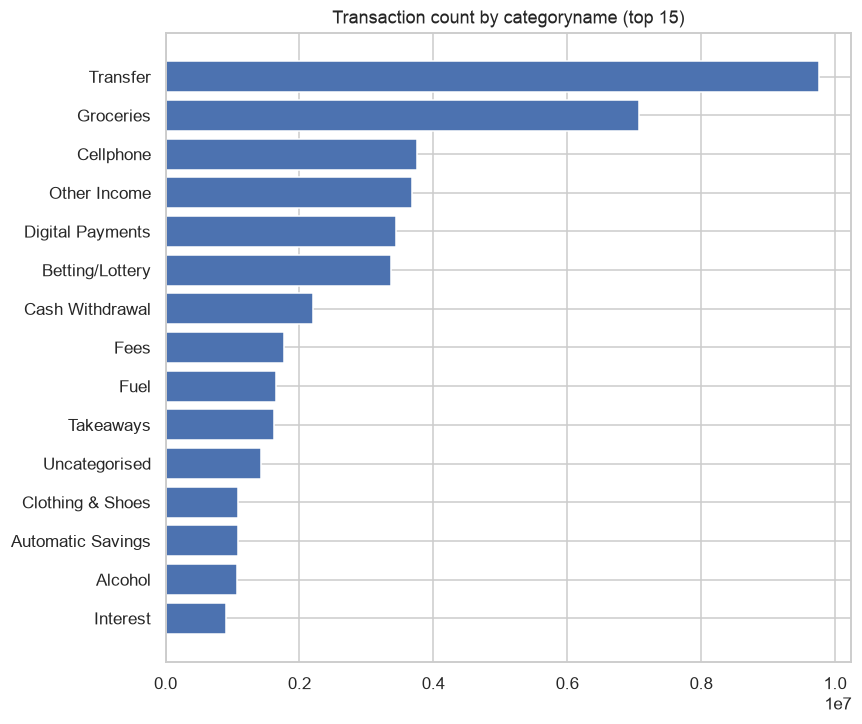

In [14]:
# Categorical structure of transactions
for col in [TXN_TYPE, SPEND, CAT]:
    if col not in txn.columns:
        continue
    g = (txn.groupby(col, observed=True)
            .agg(n=(AMT, "size"), net_amount=(AMT, "sum"), mean_amount=(AMT, "mean"),
                 pct_inflow=(AMT, lambda s: (s > 0).mean()))
            .sort_values("n", ascending=False))
    g["share_%"] = g["n"] / g["n"].sum() * 100
    print(f"\n=== {col}: {len(g)} levels (top 20 shown) ===")
    display(g.head(20))
    top = g.head(15).sort_values("n")
    fig, ax = plt.subplots(figsize=(8, 0.35 * len(top) + 1.5))
    ax.barh(top.index.astype(str), top["n"]); ax.set_title(f"Transaction count by {col} (top 15)")
    plt.tight_layout(); plt.show()

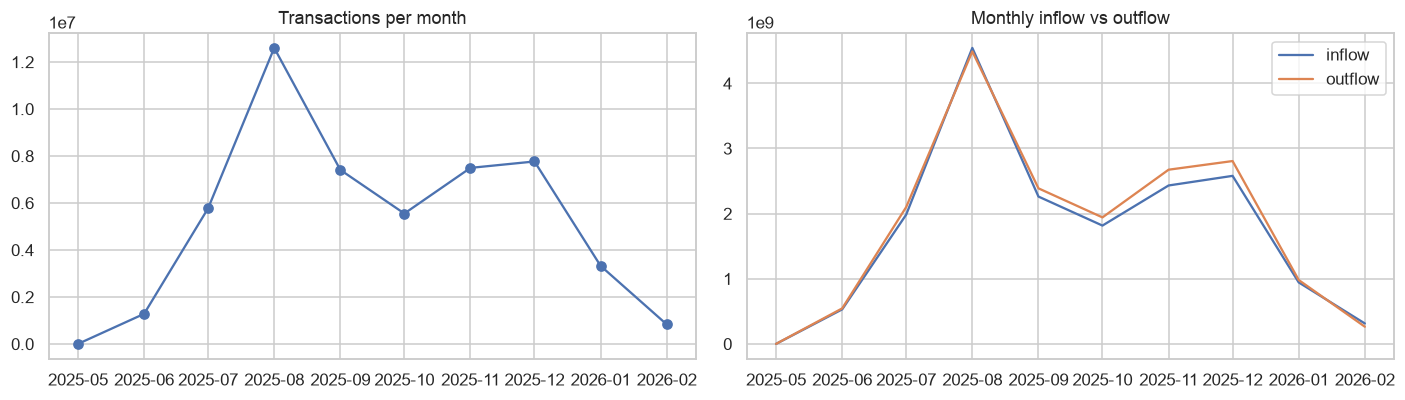

In [15]:
# Monthly volume and net flow
mt = txn.assign(month=txn[TXN_DATE].dt.to_period("M").dt.to_timestamp())
mm = mt.groupby("month").agg(n=(AMT, "size"),
                             inflow=(AMT, lambda s: s[s > 0].sum()),
                             outflow=(AMT, lambda s: -s[s < 0].sum()))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].plot(mm.index, mm["n"], marker="o"); ax[0].set_title("Transactions per month")
ax[1].plot(mm.index, mm["inflow"], label="inflow"); ax[1].plot(mm.index, mm["outflow"], label="outflow")
ax[1].legend(); ax[1].set_title("Monthly inflow vs outflow")
plt.tight_layout(); plt.show()

## 7. Time windows and leakage checks

Features must use only information available **at or before M0**, because the target is measured in the
3 months after M0. We check how much transaction history sits before vs after M0.

Transactions dated AFTER M0 (must be excluded from features): 0 (0.00%)
Transactions within the 90-day window before M0: 86.36%


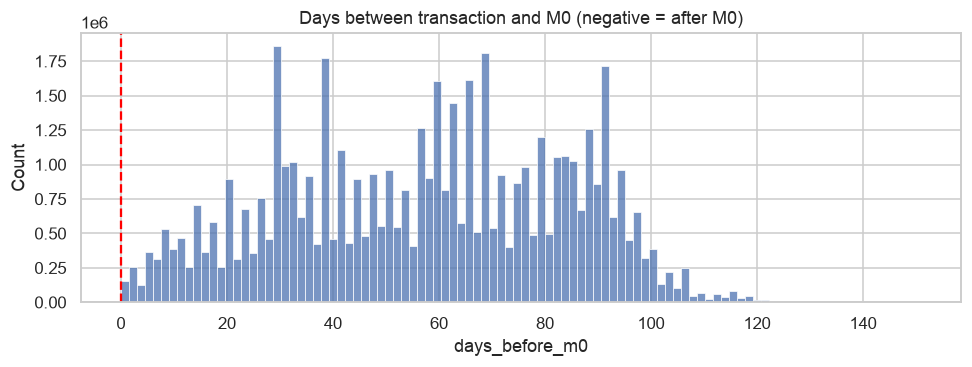

,count,mean,std,min,5%,25%,50%,75%,95%,max
max days of history before M0,"120,424.0000",98.3122,7.2952,28.0000,91.0000,93.0000,97.0000,100.0000,115.0000,151.0000


Customers in cust table with NO pre-M0 transactions: 0


,count,mean,std,min,25%,50%,75%,max
payment_date - M0 (days),"120,424.0000",-6.6604,6.9242,-30.0000,-8.0000,-5.0000,-1.0000,0.0000


In [16]:
txn["days_before_m0"] = (txn[M0] - txn[TXN_DATE]).dt.days
after = (txn["days_before_m0"] < 0)
print(f"Transactions dated AFTER M0 (must be excluded from features): {after.sum():,} ({after.mean():.2%})")
print(f"Transactions within the {WINDOW_DAYS}-day window before M0: "
      f"{((txn['days_before_m0'] >= 0) & (txn['days_before_m0'] < WINDOW_DAYS)).mean():.2%}")

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(txn["days_before_m0"].clip(-120, 400), bins=100, ax=ax)
ax.axvline(0, color="red", ls="--"); ax.set_title("Days between transaction and M0 (negative = after M0)")
plt.tight_layout(); plt.show()

# History coverage per customer (pre-M0)
pre = txn[txn["days_before_m0"] >= 0]
cov = pre.groupby(KEY, dropna=False)["days_before_m0"].max()
display(cov.describe(percentiles=[.05, .25, .5, .75, .95]).to_frame("max days of history before M0").T)
print(f"Customers in cust table with NO pre-M0 transactions: {len(cust) - len(cov):,}")

# Payment dates relative to M0
pay2 = pay.dropna(subset=[PAY_DATE, M0]).copy()
pay2["days_after_m0"] = (pay2[PAY_DATE] - pay2[M0]).dt.days
display(pay2["days_after_m0"].describe().to_frame("payment_date - M0 (days)").T)

In [17]:
# Is the transaction extract anchored on payment_date rather than on M0?
last_txn = txn.groupby(ID)[TXN_DATE].max().rename("last_txn")
chk = pay.drop_duplicates(subset=ID).set_index(ID)[[M0, PAY_DATE]].join(last_txn)
gap_pay = (chk[PAY_DATE] - chk["last_txn"]).dt.days
gap_m0 = (chk[M0] - chk["last_txn"]).dt.days
display(pd.concat([gap_pay.describe().rename("payment_date - last txn (days)"),
                   gap_m0.describe().rename("M0 - last txn (days)")], axis=1).T)
print(f"Customers whose last transaction is within 1 day of payment_date: {(gap_pay.abs() <= 1).mean():.1%}")
print("If this share is high, the extract ends at payment_date, not M0: 'days since' features measured from M0 then mostly encode the payment_date offset.")
del last_txn, chk, gap_pay, gap_m0

,count,mean,std,min,25%,50%,75%,max
payment_date - last txn (days),"120,424.0000",4.0385,6.8853,-1.0000,0.0000,0.0000,4.0000,60.0000
M0 - last txn (days),"120,424.0000",10.6989,9.4097,0.0000,4.0000,7.0000,16.0000,73.0000


Customers whose last transaction is within 1 day of payment_date: 62.8%
If this share is high, the extract ends at payment_date, not M0: 'days since' features measured from M0 then mostly encode the payment_date offset.


## 8. Feature construction: static vs time-aware

**Memory-safe design (52M-row scale).** Features are built in batches of customers from a slim, integer-keyed copy of the transactions
(customer code, days-before-M0 as int16, amount, balance, category). The large `df` / `txn` frames are freed first, so peak memory is roughly
the slim table plus one batch instead of several full-size copies.

Feature groups (disjoint), all computed strictly from transactions on or before M0 and within the last 90 days
(the extract only holds about 98 days of history per customer):

| Group | Type | Examples |
|---|---|---|
| `static` | Static account attributes | arrears amount, total due, due count, collections method |
| `snapshot` | Point-in-time | balance at M0 (last observed balance) |
| `flat` | Time-agnostic aggregates | 90-day totals, balance mean/min, share of spend by category |
| `recent` | Time-aware | the same quantities over only the last 14 and 30 days |
| `trend` | Time-aware | last 14 / 30 / 45 days vs the rest of the 90 days, per-30-day rates, for inflow, outflow, activity, balance |
| `weekly` | Time-aware | slope and volatility of weekly balance / inflow / outflow / net flow, weeks of negative net flow |
| `recency` | Time-aware | days since last inflow, longest gap between inflows, overdraft crossings |
| `cat_shift` | Time-aware | recent vs prior change in spend-category mix |

`flat` contains the *same raw information* as many time-aware features but collapses it into one window,
so `E vs C` below isolates what temporal structure adds.

In [18]:
import gc, time

# ---------------- feature settings ----------------
MAX_W = 90                # look-back used for every feature (extract holds ~98 days before M0)
FLAT_WINDOW = 90          # window for time-agnostic aggregates
N_WEEKS = 12              # weekly panel length; needs 7 * N_WEEKS <= MAX_W
BATCH_CUSTOMERS = 10_000  # customers per batch; lower this if memory is still tight
MIX_COL = CAT             # column for spend-mix features (categoryname is more meaningful than spendgroup)
MIX_EXCLUDE = ["Transfer"]  # mostly internal movements; excluded from the spend mix only
assert 7 * N_WEEKS <= MAX_W
assert cust[ID].is_unique, "Expected one row per customer; with several M0 per customer the keys must be (customer, M0)."
HAS_MIX = MIX_COL in txn.columns

# Integer customer code: much cheaper to group on than (string id, date)
codes, uniques = pd.factorize(txn[ID])
txn["cid"] = codes.astype("int32")
del codes
code_map = pd.Series(np.arange(len(uniques), dtype="int32"), index=uniques)
cust["cid"] = cust[ID].map(code_map).fillna(-1).astype("int32")
print(f"customers with transactions: {len(uniques):,} | customers in cust table without any: {(cust['cid'] < 0).sum():,}")

# Slim transaction table: only what the features need, only the look-back window, sorted by customer
keep = ["cid", "days_before_m0", AMT, BAL] + ([MIX_COL] if HAS_MIX else [])
sel = ((txn["days_before_m0"] >= 0) & (txn["days_before_m0"] < MAX_W)).to_numpy()
txn_s = txn.loc[sel, keep].rename(columns={"days_before_m0": "dbm"})
txn_s["dbm"] = txn_s["dbm"].astype("int16")
del sel

# Free the big frames (EDA sections above are finished with them)
globals().pop("df", None)
del txn
gc.collect()
txn_s = txn_s.sort_values("cid", kind="stable", ignore_index=True)
cid_arr = txn_s["cid"].to_numpy()
print(f"Slim table: {len(txn_s):,} rows, {txn_s.memory_usage(deep=True).sum() / 1e9:.2f} GB")

if HAS_MIX:
    neg = txn_s[txn_s[AMT] < 0]
    _out = (-neg[AMT]).groupby(neg[MIX_COL], observed=True).sum()
    _out = _out[~_out.index.isin(MIX_EXCLUDE)].sort_values(ascending=False)
    TOP_GROUPS = [str(g) for g in _out.head(12).index]
    TOP6 = TOP_GROUPS[:6]
    del neg, _out
    print("Top spend categories:", TOP_GROUPS)

customers with transactions: 120,424 | customers in cust table without any: 0
Slim table: 44,927,971 rows, 0.67 GB
Top spend categories: ['Digital Payments', 'Cash Withdrawal', 'Groceries', 'Uncategorised', 'Other Loans & Accounts', 'Betting/Lottery', 'Clothing & Shoes', 'Fuel', 'Loan Payments', 'Children & Dependants', 'Cellphone', 'Alcohol']


In [19]:
def slog_np(A):
    return np.sign(A) * np.log1p(np.abs(A))

def clean(name):
    return str(name).lower().replace(" ", "_").replace("/", "_").replace("&", "and")

CID = "cid"
ZERO_COLS = ["n_txn", "inflow", "outflow"]

def prep(h):
    """Within-customer chronological order (oldest first) and helper columns, in float64 for accurate sums."""
    h = h.sort_values([CID, "dbm"], ascending=[True, False]).astype({AMT: "float64", BAL: "float64"})
    h = h.assign(inflow=h[AMT].clip(lower=0), outflow=(-h[AMT]).clip(lower=0),
                 is_in=(h[AMT] > 0).astype("int8"), is_out=(h[AMT] < 0).astype("int8"),
                 neg_bal=(h[BAL] < 0).astype("int8"))
    if HAS_MIX:
        h[MIX_COL] = h[MIX_COL].astype(str)
    return h

def win_agg(h, lo, hi, idx):
    """Aggregates over days-before-M0 in [lo, hi), aligned to every customer in idx."""
    d = h[(h["dbm"] >= lo) & (h["dbm"] < hi)]
    out = (d.groupby(CID)
             .agg(n_txn=(AMT, "size"), inflow=("inflow", "sum"), outflow=("outflow", "sum"),
                  bal_mean=(BAL, "mean"), bal_min=(BAL, "min"), pct_neg=("neg_bal", "mean"))
             .reindex(idx))
    out[ZERO_COLS] = out[ZERO_COLS].fillna(0)
    out["net"] = out["inflow"] - out["outflow"]
    return out

def spend_share(h, lo, hi, groups, idx):
    d = h[(h["dbm"] >= lo) & (h["dbm"] < hi) & (h[AMT] < 0) & (~h[MIX_COL].isin(MIX_EXCLUDE))]
    if len(d) == 0:
        return pd.DataFrame(np.nan, index=idx, columns=groups)
    sp_all = d.groupby([CID, MIX_COL])["outflow"].sum().unstack(fill_value=0)
    total = sp_all.sum(axis=1).replace(0, np.nan)
    sp = sp_all.reindex(columns=groups, fill_value=0)
    return sp.div(total, axis=0).reindex(idx)

def row_slope(M):
    """OLS slope per row of a (customers x weeks) matrix, NaN-aware. x increases toward M0."""
    A = M.to_numpy(dtype=float)
    x = np.arange(A.shape[1], dtype=float)
    mask = ~np.isnan(A)
    n = mask.sum(1)
    Af = np.where(mask, A, 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        xm = (mask * x).sum(1) / n
        ym = Af.sum(1) / n
        dx = (x[None, :] - xm[:, None]) * mask
        num = (dx * (Af - ym[:, None])).sum(1)
        den = (dx ** 2).sum(1)
        out = np.where((n >= 3) & (den > 0), num / den, np.nan)
    return pd.Series(out, index=M.index)

def build_snapshot(h, idx):
    s = h.groupby(CID)[BAL].last().reindex(idx).rename("bal_at_m0").to_frame()
    s["no_history"] = s["bal_at_m0"].isna().astype("int8")
    return s

def build_flat(h, idx):
    """Time-agnostic aggregates over one window."""
    W = FLAT_WINDOW
    f = win_agg(h, 0, W, idx).add_suffix(f"_{W}d")
    d = h[h["dbm"] < W]
    ex = (d.groupby(CID)
            .agg(n_inflow=("is_in", "sum"), n_outflow=("is_out", "sum"),
                 max_inflow=("inflow", "max"), max_outflow=("outflow", "max"), bal_std=(BAL, "std"))
            .reindex(idx).add_suffix(f"_{W}d"))
    ex[[f"n_inflow_{W}d", f"n_outflow_{W}d"]] = ex[[f"n_inflow_{W}d", f"n_outflow_{W}d"]].fillna(0)
    f = f.join(ex)
    f[f"outflow_to_inflow_{W}d"] = f[f"outflow_{W}d"] / f[f"inflow_{W}d"].replace(0, np.nan)
    f[f"avg_outflow_size_{W}d"] = f[f"outflow_{W}d"] / f[f"n_outflow_{W}d"].replace(0, np.nan)
    f[f"avg_inflow_size_{W}d"] = f[f"inflow_{W}d"] / f[f"n_inflow_{W}d"].replace(0, np.nan)
    inc = d[d[AMT] > 0].groupby(CID)[AMT].agg(["mean", "std"]).reindex(idx)
    f[f"inflow_cv_{W}d"] = inc["std"] / inc["mean"]
    if HAS_MIX:
        sh = spend_share(h, 0, W, TOP_GROUPS, idx)
        sh.columns = [f"share_{clean(c)}_{W}d" for c in sh.columns]
        f = f.join(sh)
    return f

def build_time(h, idx):
    """Time-aware features: recent levels, trends, weekly dynamics, recency, mix shift."""
    r14, p76 = win_agg(h, 0, 14, idx), win_agg(h, 14, MAX_W, idx)
    r30, p60 = win_agg(h, 0, 30, idx), win_agg(h, 30, MAX_W, idx)
    r45, p45 = win_agg(h, 0, 45, idx), win_agg(h, 45, MAX_W, idx)
    recent = pd.concat([r14.add_suffix("_14d"), r30.add_suffix("_30d")], axis=1)

    # trends: recent window vs the rest of the look-back, both expressed as per-30-day rates
    tr = pd.DataFrame(index=idx)
    for tag, r, p, dr, dp in [("14", r14, p76, 14, MAX_W - 14), ("30", r30, p60, 30, MAX_W - 30), ("45", r45, p45, 45, MAX_W - 45)]:
        for nm in ["inflow", "outflow", "n_txn"]:
            tr[f"{nm}_trend{tag}"] = slog(r[nm] * 30.0 / dr) - slog(p[nm] * 30.0 / dp)
        tr[f"bal_mean_delta{tag}"] = r["bal_mean"] - p["bal_mean"]
        tr[f"pct_neg_delta{tag}"] = r["pct_neg"] - p["pct_neg"]

    # weekly panel: slope and volatility
    d = h[h["dbm"] < 7 * N_WEEKS]
    d = d.assign(wk=((N_WEEKS - 1) - (d["dbm"] // 7)).astype("int16"))   # 0 = oldest week, N_WEEKS-1 = week before M0
    g = d.groupby([CID, "wk"])
    cols_ = range(N_WEEKS)
    inflow = g["inflow"].sum().unstack("wk").reindex(index=idx, columns=cols_).fillna(0)
    outflow = g["outflow"].sum().unstack("wk").reindex(index=idx, columns=cols_).fillna(0)
    bal = g[BAL].last().unstack("wk").reindex(index=idx, columns=cols_).ffill(axis=1)
    net = inflow - outflow
    wk = pd.DataFrame(index=idx)
    wk["bal_slope"] = row_slope(bal)
    wk["inflow_slope"] = row_slope(inflow)
    wk["outflow_slope"] = row_slope(outflow)
    wk["net_slope"] = row_slope(net)
    wk["net_std"] = net.std(axis=1)
    wk["bal_wk_std"] = bal.std(axis=1)
    wk["weeks_net_neg"] = (net < 0).sum(axis=1)
    wk["weeks_bal_neg"] = (bal < 0).sum(axis=1)
    wk["bal_drawdown"] = bal.iloc[:, -1] - bal.max(axis=1)
    wk["weeks_active"] = ((inflow + outflow) > 0).sum(axis=1)

    # recency and gaps (measured from M0; see the anchor check in section 7)
    gk = h.groupby(CID)
    rec = pd.DataFrame({"days_since_last_txn": gk["dbm"].min()})
    pos = h[h[AMT] > 0]
    rec["days_since_last_inflow"] = pos.groupby(CID)["dbm"].min()
    gap = pos.assign(gap=pos.groupby(CID)["dbm"].diff().abs())
    gs = gap.groupby(CID)["gap"].agg(["max", "std"])
    rec["longest_inflow_gap"] = gs["max"]
    rec["inflow_gap_std"] = gs["std"]
    rec["days_since_nonneg_bal"] = h[h[BAL] >= 0].groupby(CID)["dbm"].min()
    prev = gk[BAL].shift(1)
    cross = ((prev >= 0) & (h[BAL] < 0)).astype("int8")
    rec["neg_crossings"] = h.assign(cross=cross).groupby(CID)["cross"].sum()
    rec = rec.reindex(idx)
    for c_ in ["days_since_last_txn", "days_since_last_inflow", "days_since_nonneg_bal", "longest_inflow_gap"]:
        rec[c_] = rec[c_].fillna(MAX_W)
    rec["neg_crossings"] = rec["neg_crossings"].fillna(0)

    parts = [recent, tr, wk, rec]
    groups = {"recent": list(recent.columns), "trend": list(tr.columns),
              "weekly": list(wk.columns), "recency": list(rec.columns)}
    if HAS_MIX:
        cs = spend_share(h, 0, 30, TOP6, idx).fillna(0) - spend_share(h, 30, MAX_W, TOP6, idx).fillna(0)
        cs.columns = [f"shift_{clean(c)}" for c in cs.columns]
        parts.append(cs)
        groups["cat_shift"] = list(cs.columns)
    else:
        groups["cat_shift"] = []
    panels = {"balance": bal, "net_flow": net, "outflow": outflow}
    return pd.concat(parts, axis=1), groups, panels

# ---------------- batch driver ----------------
cust_cids = np.sort(cust.loc[cust["cid"] >= 0, "cid"].to_numpy())
BOUNDS = np.arange(0, len(uniques) + BATCH_CUSTOMERS, BATCH_CUSTOMERS)

def shuffle_timing(h, seed):
    """Placebo: randomly reassign the days-before-M0 of each customer's transactions within that customer."""
    h = h.sort_values([CID, "dbm"]).reset_index(drop=True)
    grp = pd.factorize(h[CID])[0]
    r = np.random.default_rng(seed).random(len(h))
    order = np.lexsort((r, grp))                 # random order inside each customer block
    h["dbm"] = h["dbm"].to_numpy()[order]
    return h

def run_batches(parts=("snap", "flat", "time"), shuffle_seed=None, verbose=True):
    out = {"snap": [], "flat": [], "time": []}
    panels, groups, t0, dropped = [], None, time.time(), 0
    nb = len(BOUNDS) - 1
    for b in range(nb):
        lo, hi = BOUNDS[b], BOUNDS[b + 1]
        idx_b = pd.Index(cust_cids[(cust_cids >= lo) & (cust_cids < hi)], name=CID)
        if len(idx_b) == 0:
            continue
        a, z = np.searchsorted(cid_arr, [lo, hi])
        h = txn_s.iloc[a:z].copy()
        if DEDUPE_TXNS:
            n0 = len(h); h = h.drop_duplicates(); dropped += n0 - len(h)
        if shuffle_seed is not None:
            h = shuffle_timing(h, shuffle_seed + b)
        h = prep(h)
        if "snap" in parts: out["snap"].append(build_snapshot(h, idx_b))
        if "flat" in parts: out["flat"].append(build_flat(h, idx_b))
        if "time" in parts:
            t_, groups, p_ = build_time(h, idx_b)
            out["time"].append(t_); panels.append(p_)
        if verbose:
            print(f"batch {b + 1}/{nb}: {len(idx_b):,} customers, {z - a:,} rows, {time.time() - t0:,.0f}s elapsed")
        del h
    res = {k: (pd.concat(v) if v else None) for k, v in out.items()}
    res["groups"] = groups
    res["panels"] = ({k: pd.concat([p[k] for p in panels]) for k in panels[0]} if panels else {})
    if DEDUPE_TXNS and verbose:
        print(f"Duplicate transaction rows dropped: {dropped:,}")
    return res

def to_base(df_):
    """Re-index a customer-code-indexed frame to the (customer, M0) index of `base`."""
    out = df_.reindex(cust["cid"].to_numpy())
    out.index = base.index
    return out

In [20]:
base = cust.set_index(KEY)
y = base[TARGET].astype(int)

# ---- static attributes (known at M0, not derived from transactions)
acct_cols = [c_ for c_ in ["m0_arrearsamount", "m0_total_due_with_arrears", "due_count"] if c_ in base.columns]
static_df = base[acct_cols].copy()
if {"m0_arrearsamount", "m0_total_due_with_arrears"} <= set(base.columns):
    static_df["arrears_share_of_due"] = base["m0_arrearsamount"] / base["m0_total_due_with_arrears"].replace(0, np.nan)
if METHOD in base.columns:
    static_df = static_df.join(pd.get_dummies(base[METHOD].astype(str), prefix="method", dtype=float))

# ---- everything transaction-based, built batch by batch
RES = run_batches()
snap = to_base(RES["snap"]); snap["no_history"] = snap["no_history"].fillna(1)
flat_df = to_base(RES["flat"])
time_df = to_base(RES["time"])
PANELS = {k: to_base(v) for k, v in RES["panels"].items()}
TG = RES["groups"]
del RES; gc.collect()

X = pd.concat([static_df, snap, flat_df, time_df], axis=1).replace([np.inf, -np.inf], np.nan)
assert len(X) == len(cust)
GROUPS = {"static": list(static_df.columns), "snapshot": list(snap.columns), "flat": list(flat_df.columns), **TG}
col2grp = {c_: g_ for g_, cs_ in GROUPS.items() for c_ in cs_}
TIME_GROUPS = ["recent", "trend", "weekly", "recency", "cat_shift"]

def cols(*groups):
    return [c_ for g_ in groups for c_ in GROUPS[g_]]

SETS = {
    "A_static":               cols("static"),
    "B_static+snapshot":      cols("static", "snapshot"),
    "C_static+snap+flat":     cols("static", "snapshot", "flat"),
    "D_time_aware_only":      cols(*TIME_GROUPS),
    "E_full":                 cols("static", "snapshot", "flat", *TIME_GROUPS),
}
print(f"Feature matrix: {X.shape}")
display(pd.Series({g_: len(v) for g_, v in GROUPS.items()}, name="n_features").to_frame())
display(pd.Series({k: len(v) for k, v in SETS.items()}, name="n_features").to_frame())
display(X.isna().mean().sort_values(ascending=False).head(10).to_frame("missing share"))

batch 1/13: 10,000 customers, 6,208,425 rows, 5s elapsed
batch 2/13: 10,000 customers, 5,660,423 rows, 10s elapsed
batch 3/13: 10,000 customers, 5,088,813 rows, 15s elapsed
batch 4/13: 10,000 customers, 4,658,843 rows, 19s elapsed
batch 5/13: 10,000 customers, 4,253,112 rows, 22s elapsed
batch 6/13: 10,000 customers, 4,044,436 rows, 26s elapsed
batch 7/13: 10,000 customers, 3,720,459 rows, 29s elapsed
batch 8/13: 10,000 customers, 3,347,275 rows, 32s elapsed
batch 9/13: 10,000 customers, 2,893,680 rows, 35s elapsed
batch 10/13: 10,000 customers, 2,357,644 rows, 37s elapsed
batch 11/13: 10,000 customers, 1,741,959 rows, 39s elapsed
batch 12/13: 10,000 customers, 945,764 rows, 40s elapsed
batch 13/13: 424 customers, 7,138 rows, 40s elapsed
Feature matrix: (120424, 88)


,n_features
static,7
snapshot,2
flat,28
recent,14
trend,15
weekly,10
recency,6
cat_shift,6


,n_features
A_static,7
B_static+snapshot,9
C_static+snap+flat,37
D_time_aware_only,51
E_full,88


,missing share
pct_neg_delta14,0.3180
pct_neg_14d,0.3180
bal_min_14d,0.3180
bal_mean_14d,0.3180
bal_mean_delta14,0.3180
pct_neg_delta30,0.0401
bal_mean_delta30,0.0401
bal_min_30d,0.0401
bal_mean_30d,0.0401
pct_neg_30d,0.0401


## 9. Exploratory view of the temporal signal

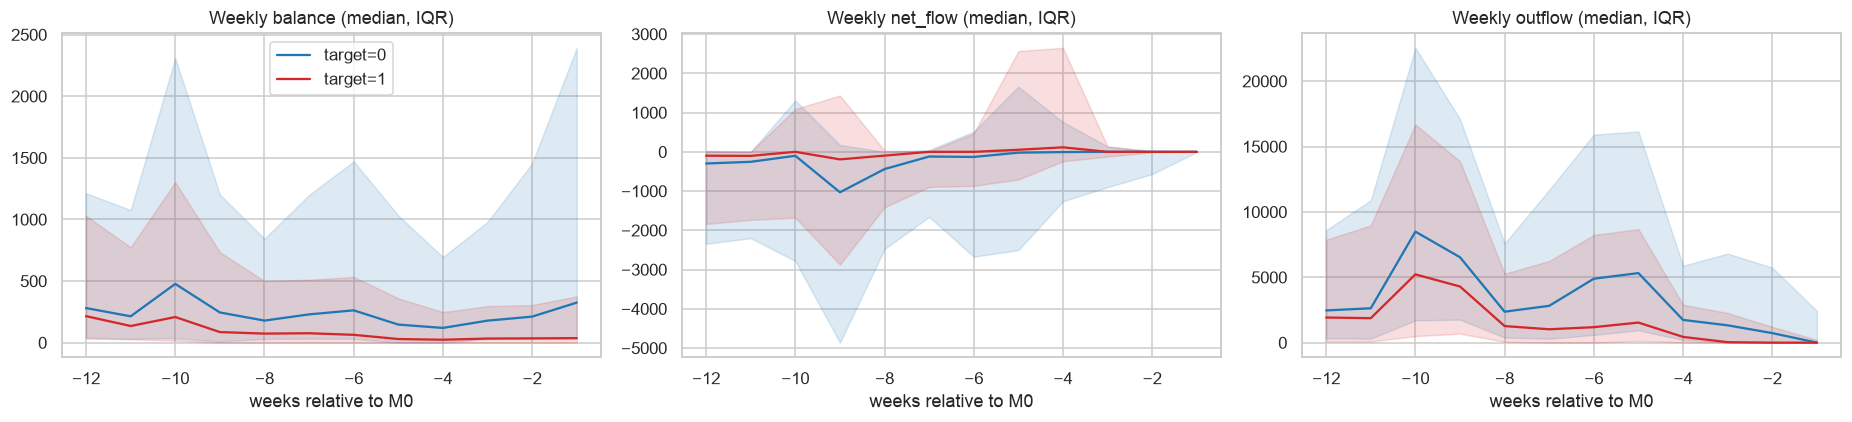

In [21]:
# Weekly trajectories before M0, by outcome: do future non-payers already look different over time?
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
xw = np.arange(N_WEEKS) - N_WEEKS
for ax, (name, M) in zip(axes, PANELS.items()):
    for t, colr in [(0, "tab:blue"), (1, "tab:red")]:
        sub = M[(y.values == t)]
        med, q1, q3 = sub.median(), sub.quantile(.25), sub.quantile(.75)
        ax.plot(xw, med.values, color=colr, label=f"target={t}")
        ax.fill_between(xw, q1.values, q3.values, color=colr, alpha=.15)
    ax.set_title(f"Weekly {name} (median, IQR)"); ax.set_xlabel("weeks relative to M0")
axes[0].legend()
plt.tight_layout(); plt.show()

,group,AUC,separation,p_value
feature,,,,
outflow_30d,recent,0.3300,0.3400,0.0000
bal_at_m0,snapshot,0.3496,0.3007,0.0000
outflow_trend45,trend,0.3536,0.2929,0.0000
outflow_14d,recent,0.3631,0.2738,0.0000
weeks_net_neg,weekly,0.3634,0.2732,0.0000
arrears_share_of_due,static,0.6354,0.2709,0.0000
bal_mean_14d,recent,0.3667,0.2666,0.0000
bal_mean_30d,recent,0.3672,0.2655,0.0000
outflow_trend30,trend,0.3678,0.2645,0.0000


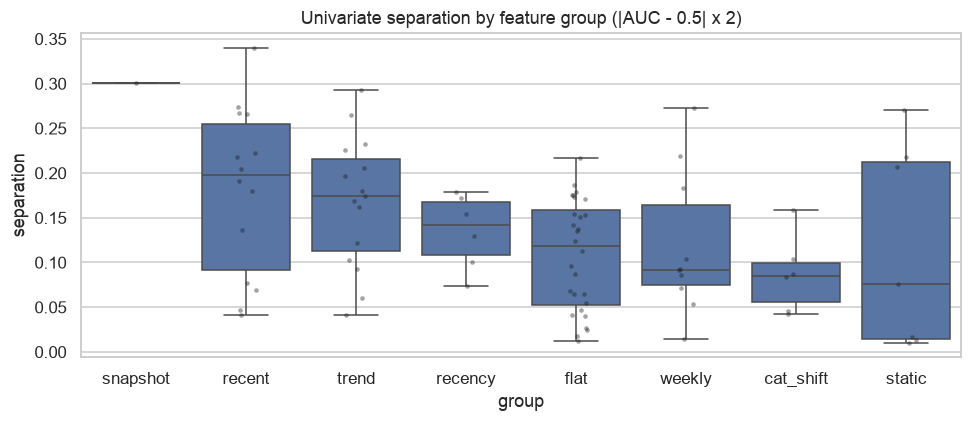

In [22]:
# Univariate separation (AUC) of every feature, tagged by group
rows = []
for c_ in X.columns:
    s = X[c_]
    a, b = s[y == 1].dropna(), s[y == 0].dropna()
    if len(a) > 20 and len(b) > 20 and s.nunique() > 1:
        u, p = stats.mannwhitneyu(a, b)
        auc = u / (len(a) * len(b))
        rows.append({"feature": c_, "group": col2grp[c_], "AUC": auc, "separation": abs(auc - 0.5) * 2, "p_value": p})
sep = pd.DataFrame(rows).set_index("feature").sort_values("separation", ascending=False)
display(sep.head(25))

order = sep.groupby("group")["separation"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=sep.reset_index(), x="group", y="separation", order=order, ax=ax)
sns.stripplot(data=sep.reset_index(), x="group", y="separation", order=order, color="k", alpha=.4, size=3, ax=ax)
ax.set_title("Univariate separation by feature group (|AUC - 0.5| x 2)")
plt.tight_layout(); plt.show()

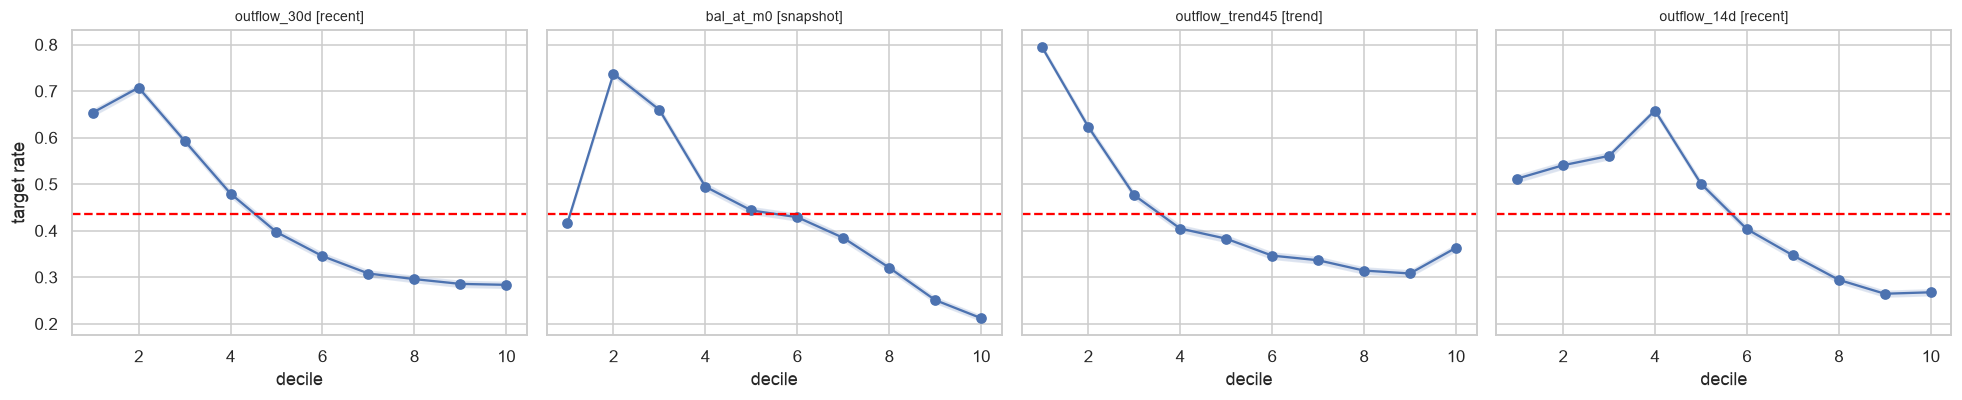

Decile edges of bal_at_m0: [-5.65966810e+05 -6.54840000e+02  0.00000000e+00  2.30000000e+01
  4.48600000e+01  1.33170000e+02  3.21990000e+02  7.60820000e+02
  2.02489000e+03  5.59685000e+03  2.00103012e+06]


,count,n_pos,rate,ci_lo,ci_hi,lift
zone,,,,,,
>1000,32807,8327,0.2538,0.2491,0.2586,0.5835
100-1000,31074,12558,0.4041,0.3987,0.4096,0.9291
0-100,26298,12852,0.4887,0.4827,0.4947,1.1235
overdrawn,15418,7606,0.4933,0.4854,0.5012,1.1341
exactly 0,14827,11039,0.7445,0.7374,0.7515,1.7116


In [23]:
# Target rate by decile for the strongest features (shows shape, incl. non-monotonic effects)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)
overall = y.mean()
for ax, c_ in zip(axes, sep.head(4).index):
    d = pd.DataFrame({"v": X[c_], "y": y}).dropna()
    d["decile"] = pd.qcut(d["v"].rank(method="first"), 10, labels=False) + 1
    g = d.groupby("decile")["y"].agg(["mean", "count", "sum"])
    lo, hi = proportion_confint(g["sum"], g["count"], method="wilson")
    ax.plot(g.index, g["mean"], marker="o"); ax.fill_between(g.index, lo, hi, alpha=.2)
    ax.axhline(overall, color="red", ls="--"); ax.set_title(f"{c_} [{col2grp[c_]}]", fontsize=9); ax.set_xlabel("decile")
axes[0].set_ylabel("target rate")
plt.tight_layout(); plt.show()

# Closing-balance shape: the notebook's first run showed a non-monotonic effect, so look at the edges and exact zeros
if "bal_at_m0" in X.columns:
    b_ = X["bal_at_m0"]
    print("Decile edges of bal_at_m0:", np.round(b_.quantile(np.linspace(0, 1, 11)).values, 2))
    zones = pd.cut(b_, [-np.inf, -1e-9, 1e-9, 100, 1000, np.inf], labels=["overdrawn", "exactly 0", "0-100", "100-1000", ">1000"])
    display(rate_table(pd.DataFrame({"zone": zones, TARGET: y}), "zone", min_n=1))

In [24]:
# Category-level risk: customers who spent in a category during the look-back window vs target rate
if HAS_MIX:
    has = txn_s[["cid", MIX_COL]].drop_duplicates().merge(cust[["cid", TARGET]], on="cid", how="left")
    rt = rate_table(has, MIX_COL, min_n=50)
    print(f"Overall target rate: {cust[TARGET].mean():.2%}")
    display(rt.sort_values("lift", ascending=False).head(15))
    display(rt.sort_values("lift").head(10))
    del has

Overall target rate: 43.50%


,count,n_pos,rate,ci_lo,ci_hi,lift
categoryname,,,,,,
Insurance Payout,191,133,0.6963,0.6278,0.7571,1.7120
Savings,14115,7780,0.5512,0.5430,0.5594,1.3551
UIF Received,5640,2924,0.5184,0.5054,0.5315,1.2746
Loans,9335,4610,0.4938,0.4837,0.5040,1.2141
Loan Payments,30144,13911,0.4615,0.4559,0.4671,1.1346
Credit Card Payments,77430,35206,0.4547,0.4512,0.4582,1.1179
Other Savings & Investments,951,427,0.4490,0.4177,0.4808,1.1039
Employee Refund,421,188,0.4466,0.3998,0.4943,1.0979
Child Support,1685,743,0.4409,0.4174,0.4648,1.0841


,count,n_pos,rate,ci_lo,ci_hi,lift
categoryname,,,,,,
Bonus,912,280,0.3070,0.2779,0.3377,0.7548
Municipal Bill,2815,885,0.3144,0.2975,0.3318,0.7729
Medical Aid,2325,735,0.3161,0.2975,0.3353,0.7772
Garden,2720,863,0.3173,0.3001,0.3350,0.7801
Other Household,3311,1056,0.3189,0.3033,0.3350,0.7841
Books/Stationery,398,127,0.3191,0.2752,0.3664,0.7845
Gifts,5753,1870,0.3250,0.3131,0.3373,0.7992
Gadgets,483,157,0.3251,0.2848,0.3681,0.7992
Pets,5188,1687,0.3252,0.3126,0.3380,0.7995


## 10. Model comparison framework

**Design**
* **Primary evaluation: out-of-time holdout.** Train on earlier M0 months, test on later ones. Customers who appear in the test period are removed from training so no customer is in both. Optional embargo (`EMBARGO_DAYS`) removes training snapshots whose outcome window overlaps the test period.
* **Same models for every feature set:** a regularised logistic regression (C tuned by inner CV) for interpretability and a gradient-boosted tree for non-linear / interaction effects. Hyperparameters are fixed identically across sets so differences come from features, not tuning.
* **Metrics:** ROC-AUC, PR-AUC, KS, Brier, log-loss, top-decile capture/lift, and out-of-sample McFadden R-squared (explanatory power).
* **Uncertainty:** paired bootstrap on the test set (same resamples for all models).

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss, log_loss,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit

SEED = 42
TEST_FRAC = 0.30        # share of (latest) M0 snapshots held out
EMBARGO_DAYS = 0        # e.g. 90 to drop training snapshots whose outcome window overlaps the test period
N_BOOT = 500            # bootstrap resamples
RUN_CV = True           # grouped K-fold robustness check
N_PLACEBO = 3           # time-shuffle repetitions
MODEL_KINDS = ["LR", "GB"]

ids = X.index.get_level_values(ID).to_numpy()
m0s = pd.Series(pd.to_datetime(X.index.get_level_values(M0)))

def make_model(kind):
    if kind == "LR":
        return Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("slog", FunctionTransformer(slog_np)),
            ("sc", StandardScaler()),
            ("clf", LogisticRegressionCV(Cs=[1e-3, 1e-2, 1e-1, 1.0], cv=3, scoring="roc_auc",
                                         max_iter=3000, n_jobs=-1)),
        ])
    return HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=400,
                                          l2_regularization=1.0, early_stopping=True,
                                          validation_fraction=0.15, n_iter_no_change=20,
                                          random_state=SEED)

# ---- out-of-time split
split_type = "out-of-time"
ok = m0s.notna().all() and m0s.nunique() >= 4
if ok:
    cutoff = m0s.quantile(1 - TEST_FRAC)
    test_mask = (m0s > cutoff).to_numpy()
    train_mask = (m0s <= cutoff - pd.Timedelta(days=EMBARGO_DAYS)).to_numpy().copy()
    train_mask &= ~np.isin(ids, ids[test_mask])
    ok = test_mask.sum() >= 200 and y.values[test_mask].sum() >= 20 and train_mask.sum() >= 200
if not ok:
    split_type = "grouped random (fallback: too few M0 months or too small a test set)"
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=SEED)
    tr_i, te_i = next(gss.split(X, y, groups=ids))
    train_mask = np.zeros(len(X), bool); train_mask[tr_i] = True
    test_mask = np.zeros(len(X), bool); test_mask[te_i] = True

Xtr, Xte = X[train_mask], X[test_mask]
ytr, yte = y.values[train_mask], y.values[test_mask]
print(f"Split type: {split_type}")
print(f"Train: {len(Xtr):,} rows, event rate {ytr.mean():.2%}, M0 {m0s[train_mask].min().date()} -> {m0s[train_mask].max().date()}")
print(f"Test : {len(Xte):,} rows, event rate {yte.mean():.2%}, M0 {m0s[test_mask].min().date()} -> {m0s[test_mask].max().date()}")
print(f"Max rows per customer in test: {pd.Series(ids[test_mask]).value_counts().max()} (1 means row bootstrap = customer bootstrap)")

Split type: out-of-time
Train: 106,017 rows, event rate 43.99%, M0 2025-09-30 -> 2026-01-31
Test : 14,407 rows, event rate 39.91%, M0 2026-02-28 -> 2026-02-28
Max rows per customer in test: 1 (1 means row bootstrap = customer bootstrap)


In [26]:
def ks_stat(y_, p_):
    fpr, tpr, _ = roc_curve(y_, p_)
    return float(np.max(tpr - fpr))

def capture_at(y_, p_, frac=0.10):
    k = max(1, int(len(p_) * frac))
    top = np.argsort(-p_)[:k]
    return float(y_[top].sum() / y_.sum())

def metrics(y_, p_, p0):
    p_ = np.clip(p_, 1e-6, 1 - 1e-6)
    ll0 = log_loss(y_, np.full(len(y_), p0))
    cap = capture_at(y_, p_)
    return {"AUC": roc_auc_score(y_, p_), "PR_AUC": average_precision_score(y_, p_), "KS": ks_stat(y_, p_),
            "Brier": brier_score_loss(y_, p_), "LogLoss": log_loss(y_, p_),
            "Top10%_capture": cap, "Top10%_lift": cap / 0.10,
            "OOS_McFadden_R2": 1 - log_loss(y_, p_) / ll0}

PRED, ROWS = {}, []
for sname, cs_ in SETS.items():
    for kind in MODEL_KINDS:
        m = make_model(kind).fit(Xtr[cs_], ytr)
        p = m.predict_proba(Xte[cs_])[:, 1]
        PRED[(sname, kind)] = p
        r = metrics(yte, p, ytr.mean()); r.update(set=sname, model=kind, n_features=len(cs_))
        ROWS.append(r)
        print(f"fitted {sname:22s} {kind}  AUC={r['AUC']:.4f}")
RESULTS = pd.DataFrame(ROWS).set_index(["model", "set"])

fitted A_static               LR  AUC=0.7205
fitted A_static               GB  AUC=0.7715
fitted B_static+snapshot      LR  AUC=0.7324
fitted B_static+snapshot      GB  AUC=0.7976
fitted C_static+snap+flat     LR  AUC=0.7382
fitted C_static+snap+flat     GB  AUC=0.8138
fitted D_time_aware_only      LR  AUC=0.7340
fitted D_time_aware_only      GB  AUC=0.7854
fitted E_full                 LR  AUC=0.7848
fitted E_full                 GB  AUC=0.8317


## 11. Results: static vs time-aware

,,AUC,PR_AUC,KS,Brier,LogLoss,Top10%_capture,Top10%_lift,OOS_McFadden_R2,n_features
model,set,,,,,,,,,
LR,A_static,0.7205,0.6015,0.3282,0.2107,0.6112,0.1697,1.6974,0.0960,7
GB,A_static,0.7715,0.6971,0.3996,0.1885,0.5592,0.2096,2.0957,0.1728,7
LR,B_static+snapshot,0.7324,0.6000,0.3561,0.2065,0.6016,0.1612,1.6122,0.1101,9
GB,B_static+snapshot,0.7976,0.7361,0.4452,0.1770,0.5310,0.2214,2.2139,0.2146,9
LR,C_static+snap+flat,0.7382,0.6272,0.3627,0.2021,0.5907,0.1830,1.8296,0.1263,37
GB,C_static+snap+flat,0.8138,0.7513,0.4742,0.1705,0.5155,0.2214,2.2139,0.2375,37
LR,D_time_aware_only,0.7340,0.6780,0.3683,0.1992,0.5856,0.2101,2.1009,0.1338,51
GB,D_time_aware_only,0.7854,0.7247,0.4283,0.1821,0.5447,0.2205,2.2052,0.1942,51
LR,E_full,0.7848,0.7204,0.4330,0.1823,0.5450,0.2188,2.1878,0.1938,88


,,AUC,lo,hi
model,set,,,
LR,A_static,0.7205,0.7115,0.7290
GB,A_static,0.7715,0.7637,0.7796
LR,B_static+snapshot,0.7324,0.7234,0.7404
GB,B_static+snapshot,0.7976,0.7895,0.8041
LR,C_static+snap+flat,0.7382,0.7298,0.7462
GB,C_static+snap+flat,0.8138,0.8062,0.8205
LR,D_time_aware_only,0.7340,0.7256,0.7425
GB,D_time_aware_only,0.7854,0.7776,0.7925
LR,E_full,0.7848,0.7773,0.7917


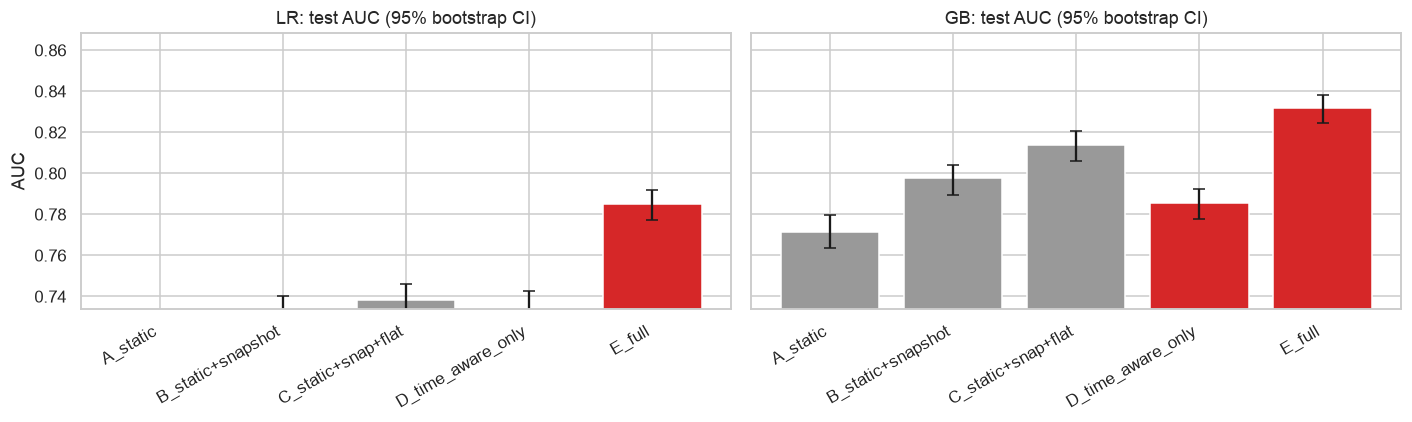

In [27]:
display(RESULTS.round(4))

# AUC bootstrap CIs (shared resamples => paired comparisons)
keys = list(PRED.keys())
rng = np.random.default_rng(SEED)
n = len(yte)
BOOT = np.full((N_BOOT, len(keys)), np.nan)
for b in range(N_BOOT):
    i = rng.integers(0, n, n)
    yy = yte[i]
    if yy.min() == yy.max():
        continue
    for j, k in enumerate(keys):
        BOOT[b, j] = roc_auc_score(yy, PRED[k][i])
kidx = {k: j for j, k in enumerate(keys)}
ci = pd.DataFrame({"AUC": [RESULTS.loc[(k[1], k[0]), "AUC"] for k in keys],
                   "lo": np.nanpercentile(BOOT, 2.5, axis=0), "hi": np.nanpercentile(BOOT, 97.5, axis=0)},
                  index=pd.MultiIndex.from_tuples([(k[1], k[0]) for k in keys], names=["model", "set"]))
display(ci.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, kind in zip(axes, MODEL_KINDS):
    sub = ci.loc[kind]
    ax.bar(range(len(sub)), sub["AUC"], yerr=[sub["AUC"] - sub["lo"], sub["hi"] - sub["AUC"]], capsize=4,
           color=["#999", "#999", "#999", "#d62728", "#d62728"][:len(sub)])
    ax.set_xticks(range(len(sub))); ax.set_xticklabels(sub.index, rotation=30, ha="right")
    ax.set_title(f"{kind}: test AUC (95% bootstrap CI)")
    ax.set_ylim(max(0.45, sub["lo"].min() - 0.03), min(1.0, sub["hi"].max() + 0.03))
axes[0].set_ylabel("AUC")
plt.tight_layout(); plt.show()

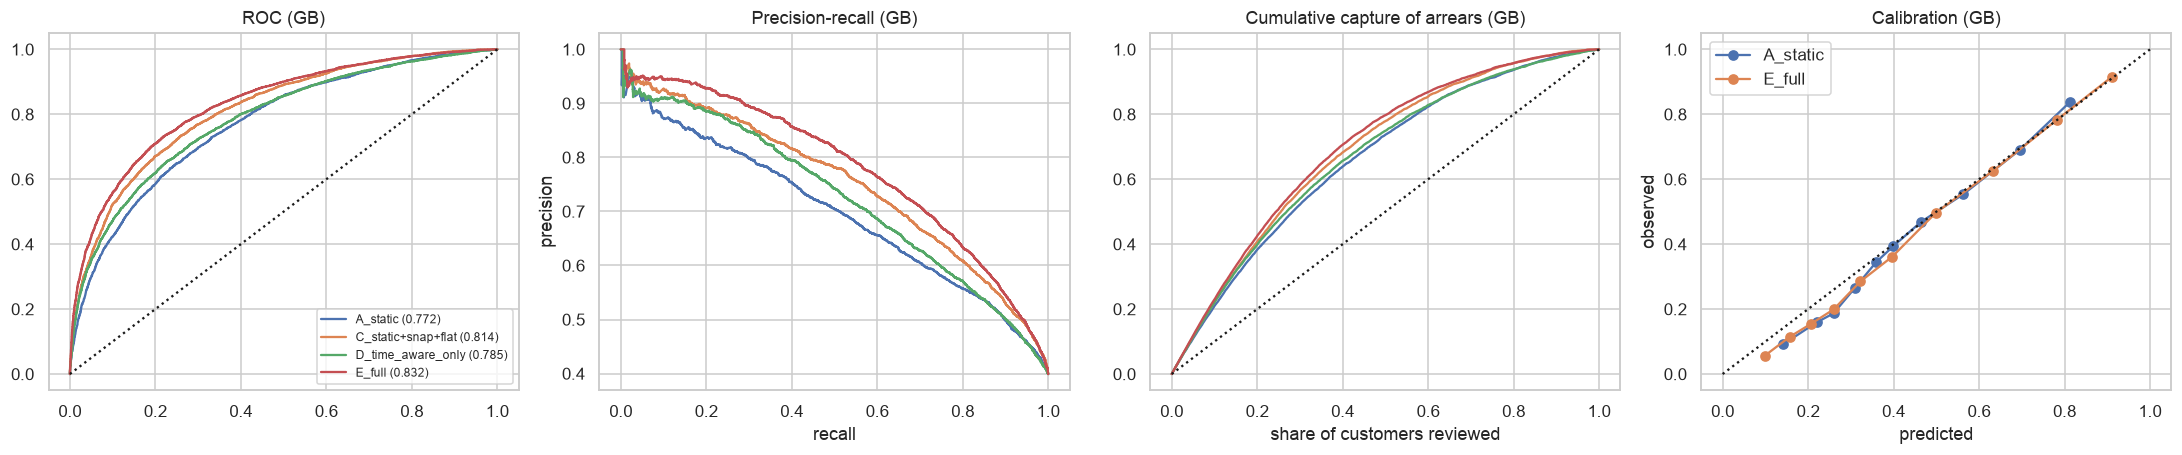

In [28]:
# ROC / PR curves, lift and calibration (gradient boosting)
show = ["A_static", "C_static+snap+flat", "D_time_aware_only", "E_full"]
fig, ax = plt.subplots(1, 4, figsize=(20, 4.3))
for s_ in show:
    p = PRED[(s_, "GB")]
    fpr, tpr, _ = roc_curve(yte, p); ax[0].plot(fpr, tpr, label=f"{s_} ({roc_auc_score(yte, p):.3f})")
    pr, rc, _ = precision_recall_curve(yte, p); ax[1].plot(rc, pr, label=s_)
    order_ = np.argsort(-p); cum = np.cumsum(yte[order_]) / yte.sum()
    ax[2].plot(np.arange(1, len(p) + 1) / len(p), cum, label=s_)
for s_ in ["A_static", "E_full"]:
    fp, mp = calibration_curve(yte, PRED[(s_, "GB")], n_bins=10, strategy="quantile")
    ax[3].plot(mp, fp, marker="o", label=s_)
ax[0].plot([0, 1], [0, 1], "k:"); ax[0].set_title("ROC (GB)"); ax[0].legend(fontsize=8)
ax[1].set_title("Precision-recall (GB)"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[2].plot([0, 1], [0, 1], "k:"); ax[2].set_title("Cumulative capture of arrears (GB)"); ax[2].set_xlabel("share of customers reviewed")
ax[3].plot([0, 1], [0, 1], "k:"); ax[3].set_title("Calibration (GB)"); ax[3].set_xlabel("predicted"); ax[3].set_ylabel("observed"); ax[3].legend()
plt.tight_layout(); plt.show()

## 12. Statistical significance and explanatory power

In [29]:
# Paired bootstrap of AUC differences on the test set
COMPARE = [
    ("D_time_aware_only", "A_static",           "H1: time-aware alone vs static alone"),
    ("E_full",            "C_static+snap+flat", "H2: add time-aware on top of best non-temporal baseline"),
    ("E_full",            "A_static",           "Full vs static"),
    ("C_static+snap+flat", "A_static",          "Non-temporal transaction info vs static"),
    ("D_time_aware_only", "C_static+snap+flat", "Time-aware alone vs non-temporal baseline"),
]
RES_DIFF, rows = {}, []
for kind in MODEL_KINDS:
    for new, ref, label in COMPARE:
        d = BOOT[:, kidx[(new, kind)]] - BOOT[:, kidx[(ref, kind)]]
        d = d[~np.isnan(d)]
        mean = RESULTS.loc[(kind, new), "AUC"] - RESULTS.loc[(kind, ref), "AUC"]
        lo, hi = np.percentile(d, [2.5, 97.5])
        p = min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()))
        RES_DIFF[(kind, new, ref)] = (mean, lo, hi, p)
        rows.append({"model": kind, "comparison": label, "new": new, "ref": ref,
                     "dAUC": mean, "CI_lo": lo, "CI_hi": hi, "p_boot": p,
                     "dTop10_capture": RESULTS.loc[(kind, new), "Top10%_capture"] - RESULTS.loc[(kind, ref), "Top10%_capture"],
                     "dOOS_R2": RESULTS.loc[(kind, new), "OOS_McFadden_R2"] - RESULTS.loc[(kind, ref), "OOS_McFadden_R2"]})
display(pd.DataFrame(rows).round(4))

,model,comparison,new,ref,dAUC,CI_lo,CI_hi,p_boot,dTop10_capture,dOOS_R2
0,LR,H1: time-aware alone vs static alone,D_time_aware_only,A_static,0.0136,0.0038,0.0241,0.0120,0.0403,0.0378
1,LR,H2: add time-aware on top of best non-temporal...,E_full,C_static+snap+flat,0.0467,0.0410,0.0519,0.0000,0.0358,0.0675
2,LR,Full vs static,E_full,A_static,0.0644,0.0579,0.0710,0.0000,0.0490,0.0978
3,LR,Non-temporal transaction info vs static,C_static+snap+flat,A_static,0.0177,0.0118,0.0233,0.0000,0.0132,0.0303
4,LR,Time-aware alone vs non-temporal baseline,D_time_aware_only,C_static+snap+flat,-0.0041,-0.0134,0.0049,0.3360,0.0271,0.0075
5,GB,H1: time-aware alone vs static alone,D_time_aware_only,A_static,0.0139,0.0052,0.0221,0.0040,0.0110,0.0215
6,GB,H2: add time-aware on top of best non-temporal...,E_full,C_static+snap+flat,0.0179,0.0140,0.0216,0.0000,0.0082,0.0327
7,GB,Full vs static,E_full,A_static,0.0602,0.0541,0.0656,0.0000,0.0200,0.0974
8,GB,Non-temporal transaction info vs static,C_static+snap+flat,A_static,0.0423,0.0370,0.0473,0.0000,0.0118,0.0647
9,GB,Time-aware alone vs non-temporal baseline,D_time_aware_only,C_static+snap+flat,-0.0285,-0.0354,-0.0220,0.0000,-0.0009,-0.0433


In [30]:
# Nested likelihood-ratio tests (in-sample, training data, near-unpenalised logistic regression).
# A subset of B subset of C subset of E, so all comparisons are nested.
from scipy.stats import chi2

def fit_ll(cs_):
    pp = Pipeline([("imp", SimpleImputer(strategy="median")), ("slog", FunctionTransformer(slog_np)), ("sc", StandardScaler())])
    Z = pp.fit_transform(Xtr[cs_])
    m = LogisticRegression(C=1e6, max_iter=5000).fit(Z, ytr)
    ll = -log_loss(ytr, np.clip(m.predict_proba(Z)[:, 1], 1e-9, 1 - 1e-9), normalize=False)
    return ll, Z.shape[1]

LL = {k: fit_ll(v) for k, v in SETS.items() if k != "D_time_aware_only"}
ntr = len(ytr)
lr_rows = []
for small, big in [("A_static", "C_static+snap+flat"), ("C_static+snap+flat", "E_full"), ("A_static", "E_full")]:
    (ll_s, k_s), (ll_b, k_b) = LL[small], LL[big]
    stat = max(0.0, 2 * (ll_b - ll_s)); dfree = k_b - k_s
    lr_rows.append({"reduced": small, "full": big, "LR_stat": stat, "df": dfree, "p_value": chi2.sf(stat, dfree) if dfree > 0 else np.nan,
                    "dAIC": (2 * k_b - 2 * ll_b) - (2 * k_s - 2 * ll_s),
                    "dBIC": (k_b * np.log(ntr) - 2 * ll_b) - (k_s * np.log(ntr) - 2 * ll_s)})
lr_tbl = pd.DataFrame(lr_rows)
display(lr_tbl)
print("Negative dAIC / dBIC favours the fuller model. With large n the LR test is almost always significant, so rely on effect sizes (out-of-sample AUC / R2) and BIC.")

# Out-of-sample McFadden R2 = share of null log-loss explained on unseen later-period data
display(RESULTS["OOS_McFadden_R2"].unstack("model").round(4))

,reduced,full,LR_stat,df,p_value,dAIC,dBIC
0,A_static,C_static+snap+flat,"5,914.3688",30,0.0000,"-5,854.3688","-5,567.2282"
1,C_static+snap+flat,E_full,"8,551.0215",51,0.0000,"-8,449.0215","-7,960.8824"
2,A_static,E_full,"14,465.3903",81,0.0000,"-14,303.3903","-13,528.1106"


Negative dAIC / dBIC favours the fuller model. With large n the LR test is almost always significant, so rely on effect sizes (out-of-sample AUC / R2) and BIC.


model,GB,LR
set,,
A_static,0.1728,0.0960
B_static+snapshot,0.2146,0.1101
C_static+snap+flat,0.2375,0.1263
D_time_aware_only,0.1942,0.1338
E_full,0.2702,0.1938


## 13. Ablation: which temporal features matter

,n_features,dAUC_if_removed_from_full,rm_lo,rm_hi,dAUC_if_added_to_baseline,add_lo,add_hi
group,,,,,,,
recent,14,-0.0024,-0.0040,-0.0007,0.0131,0.0098,0.0162
trend,15,-0.0047,-0.0063,-0.0030,0.0140,0.0107,0.0174
weekly,10,0.0001,-0.0007,0.0009,0.0034,0.0010,0.0061
recency,6,-0.0004,-0.0011,0.0004,-0.0030,-0.0052,-0.0010
cat_shift,6,-0.0008,-0.0018,0.0003,0.0037,0.0012,0.0061


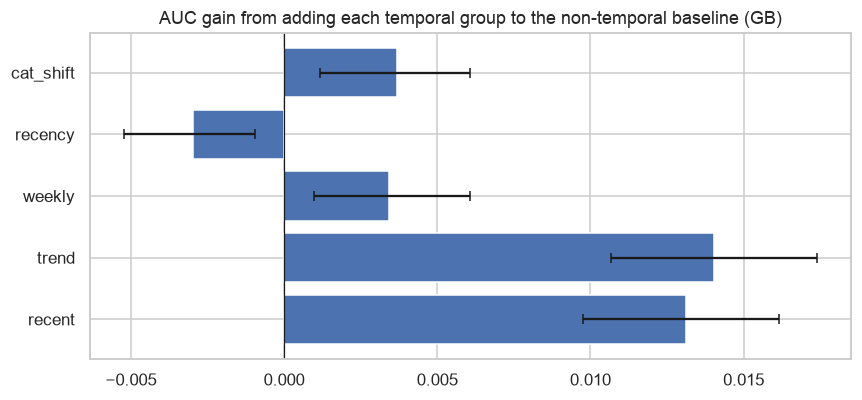

In [31]:
def paired_delta(y_, p_new, p_ref, n_boot=N_BOOT, seed=SEED):
    r = np.random.default_rng(seed); n_ = len(y_); d = []
    for _ in range(n_boot):
        i = r.integers(0, n_, n_)
        if y_[i].min() == y_[i].max():
            continue
        d.append(roc_auc_score(y_[i], p_new[i]) - roc_auc_score(y_[i], p_ref[i]))
    d = np.array(d)
    return roc_auc_score(y_, p_new) - roc_auc_score(y_, p_ref), *np.percentile(d, [2.5, 97.5])

def gb_pred(cs_):
    m = make_model("GB").fit(Xtr[cs_], ytr)
    return m.predict_proba(Xte[cs_])[:, 1]

pE = PRED[("E_full", "GB")]; pC = PRED[("C_static+snap+flat", "GB")]
rows = []
for g_ in TIME_GROUPS:
    if not GROUPS[g_]:
        continue
    # leave one temporal group out of the full model
    cs_drop = [c_ for c_ in SETS["E_full"] if col2grp[c_] != g_]
    d1 = paired_delta(yte, gb_pred(cs_drop), pE)
    # add one temporal group to the non-temporal baseline
    d2 = paired_delta(yte, gb_pred(SETS["C_static+snap+flat"] + GROUPS[g_]), pC)
    rows.append({"group": g_, "n_features": len(GROUPS[g_]),
                 "dAUC_if_removed_from_full": d1[0], "rm_lo": d1[1], "rm_hi": d1[2],
                 "dAUC_if_added_to_baseline": d2[0], "add_lo": d2[1], "add_hi": d2[2]})
abl = pd.DataFrame(rows).set_index("group")
display(abl.round(4))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(abl.index, abl["dAUC_if_added_to_baseline"],
        xerr=[abl["dAUC_if_added_to_baseline"] - abl["add_lo"], abl["add_hi"] - abl["dAUC_if_added_to_baseline"]], capsize=3)
ax.axvline(0, color="k", lw=.8); ax.set_title("AUC gain from adding each temporal group to the non-temporal baseline (GB)")
plt.tight_layout(); plt.show()

,type,AUC_drop_mean,AUC_drop_sd
group,,,
static,static/flat,0.1111,0.0025
flat,static/flat,0.0317,0.0009
trend,time-aware,0.0279,0.0010
recent,time-aware,0.0277,0.0011
snapshot,static/flat,0.0047,0.0003
cat_shift,time-aware,0.0036,0.0002
recency,time-aware,0.0012,0.0002
weekly,time-aware,0.0011,0.0002


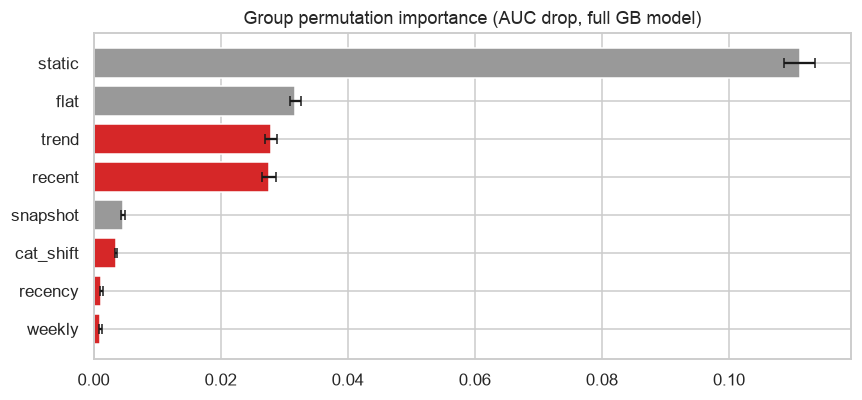

In [32]:
# Grouped permutation importance on the test set for the full GB model (permute a whole group jointly)
mE = make_model("GB").fit(Xtr[SETS["E_full"]], ytr)
base_auc = roc_auc_score(yte, mE.predict_proba(Xte[SETS["E_full"]])[:, 1])
rp = np.random.default_rng(SEED)
imp = []
for g_, cs_ in GROUPS.items():
    if not cs_:
        continue
    drops = []
    for _ in range(5):
        Xp = Xte[SETS["E_full"]].copy()
        perm = rp.permutation(len(Xp))
        Xp[cs_] = Xp[cs_].to_numpy()[perm]
        drops.append(base_auc - roc_auc_score(yte, mE.predict_proba(Xp)[:, 1]))
    imp.append({"group": g_, "type": "time-aware" if g_ in TIME_GROUPS else "static/flat",
                "AUC_drop_mean": np.mean(drops), "AUC_drop_sd": np.std(drops)})
imp = pd.DataFrame(imp).sort_values("AUC_drop_mean", ascending=False).set_index("group")
display(imp.round(4))
fig, ax = plt.subplots(figsize=(8, 3.8))
colors = ["#d62728" if t == "time-aware" else "#999" for t in imp["type"]]
ax.barh(imp.index[::-1], imp["AUC_drop_mean"][::-1], xerr=imp["AUC_drop_sd"][::-1], color=colors[::-1], capsize=3)
ax.set_title("Group permutation importance (AUC drop, full GB model)")
plt.tight_layout(); plt.show()

,feature,AUC_drop,sd,group
3,arrears_share_of_due,0.0541,0.0014,static
1,m0_total_due_with_arrears,0.0268,0.0012,static
6,"method_Early Debit Order, linked to clients pa...",0.0159,0.0011,static
62,outflow_trend45,0.0154,0.0012,trend
13,bal_min_90d,0.0149,0.0010,flat
7,bal_at_m0,0.0049,0.0007,snapshot
2,due_count,0.0049,0.0003,static
50,net_30d,0.0048,0.0005,recent
41,bal_min_14d,0.0048,0.0002,recent
19,max_outflow_90d,0.0026,0.0004,flat


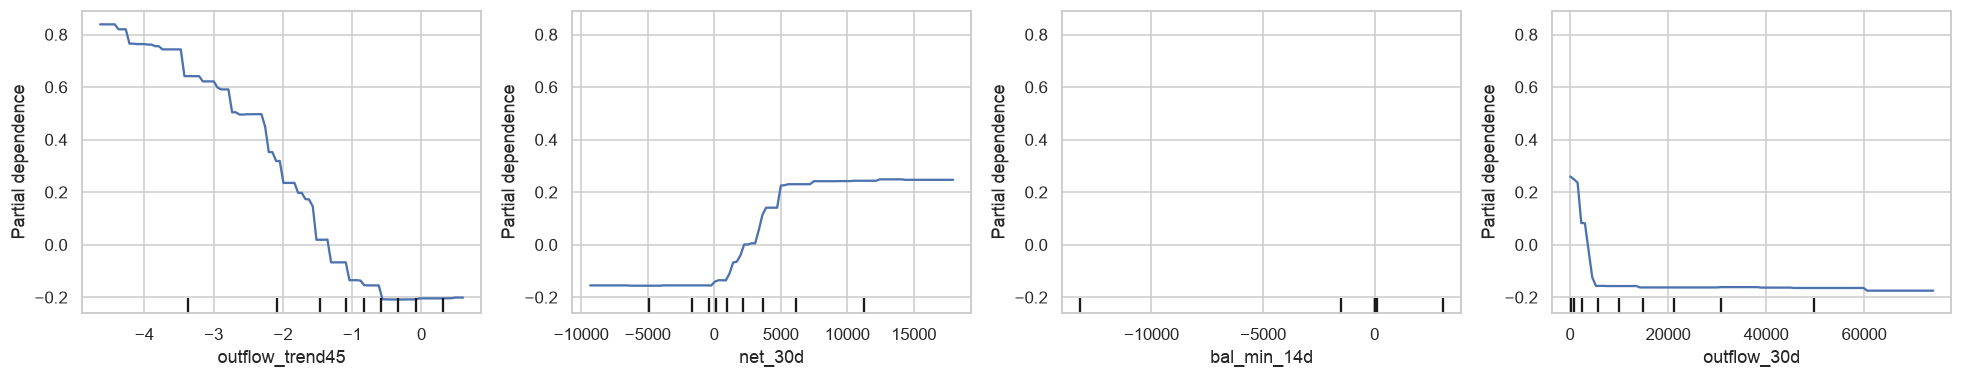

In [33]:
# Top individual features by permutation importance (full GB), with their group
from sklearn.inspection import permutation_importance
pi = permutation_importance(mE, Xte[SETS["E_full"]], yte, scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1)
pif = (pd.DataFrame({"feature": SETS["E_full"], "AUC_drop": pi.importances_mean, "sd": pi.importances_std})
         .assign(group=lambda d: d["feature"].map(col2grp)).sort_values("AUC_drop", ascending=False))
display(pif.head(20).round(4))

# Partial dependence of the top temporal features (shape of the effect)
from sklearn.inspection import PartialDependenceDisplay
top_t = [f for f in pif["feature"] if col2grp[f] in TIME_GROUPS][:4]
fig, ax = plt.subplots(1, len(top_t), figsize=(4.5 * len(top_t), 3.6))
ax = np.atleast_1d(ax)
PartialDependenceDisplay.from_estimator(mE, Xte[SETS["E_full"]], top_t, ax=ax, kind="average")
plt.tight_layout(); plt.show()

## 14. Placebo test: does *timing* matter?

For each customer we randomly reassign the **timing** of their transactions within the look-back window,
keeping amounts, balances and categories attached to the same rows. Total activity and its composition are unchanged,
but trends, slopes, recency and gaps are destroyed. We rebuild the time-aware features from the shuffled data and
refit the full model. If time-aware structure drives the gain, the placebo AUC should fall back toward the
non-temporal baseline `C`. The time-agnostic `flat` and `static` features are left untouched.

In [34]:
PLACEBO = {"GB": [], "LR": []}
PLACEBO_PRED = None
time_cols = cols(*TIME_GROUPS)
for rep in range(N_PLACEBO):
    t_sh = to_base(run_batches(parts=("time",), shuffle_seed=SEED + rep, verbose=False)["time"])
    Xp = X.copy()
    Xp[time_cols] = t_sh[time_cols].replace([np.inf, -np.inf], np.nan)
    Xp_tr, Xp_te = Xp[train_mask], Xp[test_mask]
    mg = make_model("GB").fit(Xp_tr[SETS["E_full"]], ytr)
    pg = mg.predict_proba(Xp_te[SETS["E_full"]])[:, 1]
    PLACEBO["GB"].append(roc_auc_score(yte, pg))
    if rep == 0:
        PLACEBO_PRED = pg
        ml = make_model("LR").fit(Xp_tr[SETS["E_full"]], ytr)
        PLACEBO["LR"].append(roc_auc_score(yte, ml.predict_proba(Xp_te[SETS["E_full"]])[:, 1]))
    del Xp, Xp_tr, Xp_te, t_sh
    print(f"placebo rep {rep}: GB AUC = {PLACEBO['GB'][-1]:.4f}")

tbl = pd.DataFrame({
    "A_static (GB)": [RESULTS.loc[("GB", "A_static"), "AUC"]],
    "C_non-temporal (GB)": [RESULTS.loc[("GB", "C_static+snap+flat"), "AUC"]],
    "E_full real timing (GB)": [RESULTS.loc[("GB", "E_full"), "AUC"]],
    "E_full shuffled timing (GB, mean)": [np.mean(PLACEBO["GB"])],
}).T.rename(columns={0: "test AUC"})
display(tbl.round(4))

PLACEBO_DIFF = paired_delta(yte, pE, PLACEBO_PRED)
print(f"Real minus shuffled timing (GB, rep 0): dAUC = {PLACEBO_DIFF[0]:.4f}  95% CI [{PLACEBO_DIFF[1]:.4f}, {PLACEBO_DIFF[2]:.4f}]")
PLACEBO_VS_C = paired_delta(yte, PLACEBO_PRED, pC)
print(f"Shuffled-timing full vs non-temporal baseline C: dAUC = {PLACEBO_VS_C[0]:.4f}  95% CI [{PLACEBO_VS_C[1]:.4f}, {PLACEBO_VS_C[2]:.4f}]")
print("(If this is near zero, nothing beyond the non-temporal baseline survives once timing is destroyed.)")

placebo rep 0: GB AUC = 0.8185
placebo rep 1: GB AUC = 0.8190
placebo rep 2: GB AUC = 0.8187


,test AUC
A_static (GB),0.7715
C_non-temporal (GB),0.8138
E_full real timing (GB),0.8317
"E_full shuffled timing (GB, mean)",0.8187


Real minus shuffled timing (GB, rep 0): dAUC = 0.0132  95% CI [0.0104, 0.0163]
Shuffled-timing full vs non-temporal baseline C: dAUC = 0.0046  95% CI [0.0017, 0.0076]
(If this is near zero, nothing beyond the non-temporal baseline survives once timing is destroyed.)


## 15. Robustness

,n,event_rate,A_static,C_static+snap+flat,E_full
M0 month,,,,,
2026-02,14407,0.3991,0.7715,0.8138,0.8317


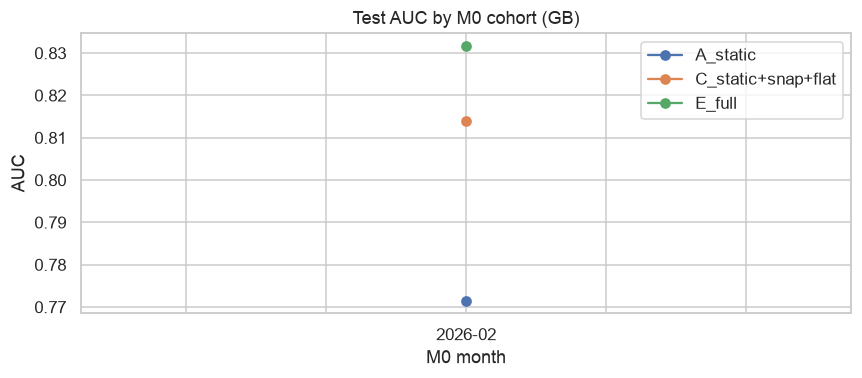

In [35]:
# (a) Stability across later M0 cohorts within the test period (GB)
tm = m0s[test_mask].dt.to_period("M").astype(str).to_numpy()
rows = []
for mth in sorted(set(tm)):
    sel = tm == mth
    if yte[sel].sum() >= 10 and (1 - yte[sel]).sum() >= 10:
        rows.append({"M0 month": mth, "n": int(sel.sum()), "event_rate": yte[sel].mean(),
                     **{s_: roc_auc_score(yte[sel], PRED[(s_, "GB")][sel]) for s_ in ["A_static", "C_static+snap+flat", "E_full"]}})
if rows:
    coh = pd.DataFrame(rows).set_index("M0 month")
    display(coh.round(4))
    ax = coh[["A_static", "C_static+snap+flat", "E_full"]].plot(marker="o", figsize=(8, 3.6), title="Test AUC by M0 cohort (GB)")
    ax.set_ylabel("AUC"); plt.tight_layout(); plt.show()
else:
    print("Not enough events per test month for a cohort breakdown.")

In [36]:
# (b) Grouped K-fold CV on all data (random, not time-ordered): checks the result is not an artefact of one split. GB only.
CV_TBL = None
if RUN_CV:
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_rows = []
    for f, (tr_i, te_i) in enumerate(sgkf.split(X, y, groups=ids)):
        rec_ = {"fold": f}
        for s_ in ["A_static", "C_static+snap+flat", "D_time_aware_only", "E_full"]:
            m = make_model("GB").fit(X.iloc[tr_i][SETS[s_]], y.values[tr_i])
            rec_[s_] = roc_auc_score(y.values[te_i], m.predict_proba(X.iloc[te_i][SETS[s_]])[:, 1])
        cv_rows.append(rec_)
    CV_TBL = pd.DataFrame(cv_rows).set_index("fold")
    display(CV_TBL.round(4))
    for new, ref in [("D_time_aware_only", "A_static"), ("E_full", "C_static+snap+flat")]:
        d = CV_TBL[new] - CV_TBL[ref]
        t, p = stats.ttest_1samp(d, 0.0)
        print(f"{new} - {ref}: mean dAUC = {d.mean():.4f} (sd {d.std():.4f}), folds positive = {(d > 0).sum()}/{len(d)}, paired t p = {p:.4f}")

,A_static,C_static+snap+flat,D_time_aware_only,E_full
fold,,,,
0,0.7453,0.7957,0.7709,0.8148
1,0.7402,0.7903,0.7697,0.8114
2,0.7427,0.7943,0.7710,0.8170
3,0.7396,0.7934,0.7760,0.8164
4,0.7479,0.7958,0.7703,0.8164


D_time_aware_only - A_static: mean dAUC = 0.0285 (sd 0.0052), folds positive = 5/5, paired t p = 0.0003
E_full - C_static+snap+flat: mean dAUC = 0.0213 (sd 0.0015), folds positive = 5/5, paired t p = 0.0000


## 16. Verdict and outputs

In [37]:
def verdict_line(label, mean, lo, hi):
    status = "SUPPORTED" if lo > 0 else ("NOT SUPPORTED" if hi < 0 else "INCONCLUSIVE (CI includes 0)")
    return f"{label:70s} dAUC={mean:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  -> {status}"

print("=" * 120)
print("TIME-AWARE vs STATIC: SUMMARY (out-of-time test set)")
print("=" * 120)
flags = []
for kind in MODEL_KINDS:
    h1 = RES_DIFF[(kind, "D_time_aware_only", "A_static")]
    h2 = RES_DIFF[(kind, "E_full", "C_static+snap+flat")]
    print(verdict_line(f"[{kind}] H1 time-aware alone > static alone", *h1[:3]))
    print(verdict_line(f"[{kind}] H2 full > non-temporal baseline (static+snapshot+flat)", *h2[:3]))
    flags += [h1[1] > 0, h2[1] > 0]
print(verdict_line("[GB]  H3 real timing > shuffled timing (placebo)", *PLACEBO_DIFF))
flags.append(PLACEBO_DIFF[1] > 0)

fp = sum(flags)
print("-" * 120)
if fp == len(flags):
    print("OVERALL: strong support. Time-aware features beat static attributes, add value beyond non-temporal aggregates, and the gain disappears when timing is shuffled.")
elif fp >= len(flags) // 2:
    print("OVERALL: partial support. Review which hypotheses were inconclusive above (sample size, model class, or weak temporal signal).")
else:
    print("OVERALL: little support in this dataset. Static or flat features capture most of the signal; revisit window lengths and feature design.")
print("Caveats: single out-of-time split (see CV for stability); bootstrap treats test rows as independent; "
      "ensure the 'static' set contains every point-in-time attribute you consider fair; results describe prediction, not causation.")

TIME-AWARE vs STATIC: SUMMARY (out-of-time test set)
[LR] H1 time-aware alone > static alone                                dAUC=+0.0136  95% CI [+0.0038, +0.0241]  -> SUPPORTED
[LR] H2 full > non-temporal baseline (static+snapshot+flat)            dAUC=+0.0467  95% CI [+0.0410, +0.0519]  -> SUPPORTED
[GB] H1 time-aware alone > static alone                                dAUC=+0.0139  95% CI [+0.0052, +0.0221]  -> SUPPORTED
[GB] H2 full > non-temporal baseline (static+snapshot+flat)            dAUC=+0.0179  95% CI [+0.0140, +0.0216]  -> SUPPORTED
[GB]  H3 real timing > shuffled timing (placebo)                       dAUC=+0.0132  95% CI [+0.0104, +0.0163]  -> SUPPORTED
------------------------------------------------------------------------------------------------------------------------
OVERALL: strong support. Time-aware features beat static attributes, add value beyond non-temporal aggregates, and the gain disappears when timing is shuffled.
Caveats: single out-of-time split (see CV

In [38]:
# Save outputs
out = X.assign(**{TARGET: y}).reset_index()
out["split"] = np.where(train_mask, "train", np.where(test_mask, "test", "unused"))
out.to_parquet(OUTPUT_PATH, index=False)
RESULTS.reset_index().to_csv("model_comparison_results.csv", index=False)
pd.Series(col2grp, name="group").rename_axis("feature").reset_index().to_csv("feature_groups.csv", index=False)
print(f"Saved {OUTPUT_PATH} ({out.shape[0]:,} x {out.shape[1]}), model_comparison_results.csv, feature_groups.csv")

Saved customer_features.parquet (120,424 x 92), model_comparison_results.csv, feature_groups.csv


### How to read and extend this
* **If H1-H3 are supported:** the temporal structure carries real signal. Use the group-importance and partial-dependence outputs to describe *which* dynamics matter (for example, declining weekly balance slope, widening inflow gaps), and take the `E_full` feature table (`customer_features.parquet`) into the SOM with the target held out.
* **If H2 holds but H3 does not:** the gain comes from richer data rather than timing. Check `flat` window choices.
* **Fairness of the "static" baseline:** add any other point-in-time attributes you hold (tenure, product, income band) to the `static` group before concluding.
* **Stronger evidence:** repeat with several different cut-off dates (rolling out-of-time), set `EMBARGO_DAYS = 90`, and add survival or discrete-time hazard models for time-to-arrears.